# Detector YOLO de Cilindros Industriais — BLAZE

Este notebook implementa o fluxo completo do módulo YOLO para detecção de cilindros industriais no projeto **BLAZE**.

Ele foi pensado para dois usos:

1. **Jupyter da UFSC**: treinamento com GPU compartilhada e seleção manual da GPU.
2. **VS Code local em Linux**: validação, inferência, webcam e vídeos após perder acesso ao servidor.

O notebook **não usa chave SSH, token ou senha**. O acesso ao repositório deve ser feito fora do notebook, pelo Git/terminal/VS Code.

## Passo 0 — Antes de abrir o notebook

No terminal, entre na pasta do BLAZE e confirme a branch:

```bash
cd caminho/para/BLAZE
git status
git branch --show-current
```

Fluxo recomendado:

```bash
git switch dev
git pull --ff-only
git switch -c feature/yolo-cylinders-notebook
```

Se você já criou uma branch para o módulo YOLO, use a branch existente.

## Passo 1 — Listar GPUs disponíveis

Esta célula usa `nvidia-smi` para mostrar quais GPUs existem no servidor e quanto de memória está livre.

No Jupyter da UFSC, execute antes de escolher a GPU. No VS Code local, se não houver GPU NVIDIA, o notebook seguirá em CPU.

In [1]:
import os
import subprocess
from pathlib import Path

try:
    import pandas as pd
except Exception:
    pd = None

def listar_gpus():
    comando = [
        "nvidia-smi",
        "--query-gpu=index,name,memory.total,memory.used,memory.free,utilization.gpu,temperature.gpu,power.draw,power.limit",
        "--format=csv,noheader,nounits"
    ]

    try:
        resultado = subprocess.check_output(comando, encoding="utf-8")
    except FileNotFoundError:
        print("nvidia-smi não encontrado. Provavelmente este ambiente não possui GPU NVIDIA configurada.")
        return pd.DataFrame([]) if pd is not None else []
    except subprocess.CalledProcessError as erro:
        print("Erro ao executar nvidia-smi:")
        print(erro)
        return pd.DataFrame([]) if pd is not None else []

    linhas = [linha for linha in resultado.strip().split("\n") if linha.strip()]
    dados = []

    for linha in linhas:
        partes = [p.strip() for p in linha.split(",")]
        dados.append({
            "GPU": int(partes[0]),
            "Nome": partes[1],
            "Memória total MiB": int(float(partes[2])),
            "Memória usada MiB": int(float(partes[3])),
            "Memória livre MiB": int(float(partes[4])),
            "Uso GPU %": int(float(partes[5])),
            "Temperatura °C": int(float(partes[6])),
            "Potência atual W": partes[7],
            "Potência limite W": partes[8],
        })

    if pd is not None:
        return pd.DataFrame(dados)

    return dados

df_gpus = listar_gpus()
df_gpus

nvidia-smi não encontrado. Provavelmente este ambiente não possui GPU NVIDIA configurada.


""


## Passo 2 — Escolher manualmente a GPU

Digite o número da GPU física escolhida.

Exemplo: se na tabela anterior a GPU mais livre é a `2`, digite `2`.

Depois desta célula, o Python/YOLO enxergará essa GPU como `device=0`.

In [2]:
# Deixe vazio para o notebook perguntar com input().
# Se preferir, escreva diretamente o número como texto. Exemplo: GPU_FISICA_ESCOLHIDA = "0"
GPU_FISICA_ESCOLHIDA = ""

if isinstance(df_gpus, list):
    gpus_disponiveis = [linha["GPU"] for linha in df_gpus]
else:
    gpus_disponiveis = df_gpus["GPU"].tolist() if len(df_gpus) > 0 else []

if len(gpus_disponiveis) == 0:
    print("Nenhuma GPU NVIDIA foi detectada. O notebook seguirá em CPU.")
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
else:
    gpu_texto = str(GPU_FISICA_ESCOLHIDA).strip()

    if gpu_texto == "":
        gpu_texto = input("Digite o número da GPU física que deseja usar: ").strip()

    if not gpu_texto.isdigit():
        raise ValueError("Digite apenas o número da GPU. Exemplo: 0, 1, 2, 3...")

    gpu_escolhida = int(gpu_texto)

    if gpu_escolhida not in gpus_disponiveis:
        raise ValueError(f"GPU {gpu_escolhida} não encontrada. GPUs disponíveis: {gpus_disponiveis}")

    # Importante: execute esta célula antes de importar torch/ultralytics.
    os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_escolhida)

    print(f"GPU física escolhida: {gpu_escolhida}")
    print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
    print("Dentro do Python/YOLO, essa GPU aparecerá como device=0.")

# Configurações auxiliares para ambiente remoto/Jupyter.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["WANDB_DISABLED"] = "true"

Nenhuma GPU NVIDIA foi detectada. O notebook seguirá em CPU.


## Passo 3 — Conferir GPU no Python

Agora o PyTorch deve enxergar apenas a GPU escolhida na célula anterior.

In [3]:
try:
    import torch

    print("CUDA disponível?", torch.cuda.is_available())
    print("Quantidade de GPUs visíveis para este notebook:", torch.cuda.device_count())

    if torch.cuda.is_available():
        print("Nome da GPU visível:", torch.cuda.get_device_name(0))
        DEVICE = 0
        DEVICE_YOLO = "0"
    else:
        DEVICE = "cpu"
        DEVICE_YOLO = "cpu"

except ImportError:
    print("PyTorch ainda não está instalado neste ambiente.")
    print("Execute a célula de instalação opcional abaixo, se necessário.")
    DEVICE = "cpu"
    DEVICE_YOLO = "cpu"

print("DEVICE usado pelo notebook:", DEVICE)
print("DEVICE_YOLO usado pelo Ultralytics:", DEVICE_YOLO)

CUDA disponível? False
Quantidade de GPUs visíveis para este notebook: 0
DEVICE usado pelo notebook: cpu
DEVICE_YOLO usado pelo Ultralytics: cpu


## Passo 4 — Instalação opcional

Use apenas se o ambiente ainda não tiver as bibliotecas necessárias.

Se instalar algo, reinicie o kernel e execute o notebook novamente desde o Passo 1.

In [4]:
# Execute somente se necessário.
# %pip install -U ultralytics pyyaml tqdm pandas matplotlib opencv-python

## Passo 5 — Importações principais

In [5]:
from pathlib import Path
import json
import random
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, clear_output

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

print("Importações concluídas.")

Importações concluídas.


## Passo 6 — Encontrar a raiz do projeto BLAZE

A célula tenta encontrar automaticamente a pasta raiz do BLAZE procurando `README.md`, `requirements.txt`, `vision/` e `jet_automation/`.

Se a detecção automática falhar, preencha manualmente `PROJECT_ROOT_MANUAL`.

In [6]:
# Caso a detecção automática falhe, preencha aqui.
# Exemplo: PROJECT_ROOT_MANUAL = "/caminho/para/BLAZE"
PROJECT_ROOT_MANUAL = ""

def encontrar_raiz_blaze(inicio=None):
    env_root = os.environ.get("BLAZE_ROOT", "").strip()
    candidatos = []

    if PROJECT_ROOT_MANUAL.strip():
        candidatos.append(Path(PROJECT_ROOT_MANUAL).expanduser())

    if env_root:
        candidatos.append(Path(env_root).expanduser())

    if inicio is None:
        inicio = Path.cwd()

    inicio = Path(inicio).resolve()
    candidatos.extend([inicio] + list(inicio.parents))

    for candidato in candidatos:
        if (
            (candidato / "README.md").exists()
            and (candidato / "requirements.txt").exists()
            and (candidato / "vision").exists()
            and (candidato / "jet_automation").exists()
        ):
            return candidato.resolve()

    raise FileNotFoundError(
        "Não consegui encontrar a raiz do BLAZE automaticamente. "
        "Preencha PROJECT_ROOT_MANUAL com o caminho da pasta BLAZE."
    )

PROJECT_ROOT = encontrar_raiz_blaze()

print("Raiz do projeto BLAZE:")
print(PROJECT_ROOT)

Raiz do projeto BLAZE:
.


## Passo 7 — Configurar caminhos do módulo YOLO

O dataset e os resultados seguem o padrão atual do BLAZE:

- Dataset externo/ignorado pelo Git: `vision/datasets/cylinders/CylinDeRS-1/`
- Resultados externos/ignorados pelo Git: `vision/results/yolo_cylinder_detector/`
- Notebook versionado: `vision/cylinders_detect/YOLO/`

In [7]:
YOLO_MODULE_DIR = PROJECT_ROOT / "vision" / "cylinders_detect" / "YOLO"

DATASET_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "CylinDeRS-1"

RESULTS_BASE_DIR = PROJECT_ROOT / "vision" / "results" / "yolo_cylinder_detector"
TRAIN_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "train"
VAL_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "val"
PRED_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "predict"
VIDEO_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "video"

DATA_YAML_ORIGINAL = DATASET_DIR / "data.yaml"
DATA_YAML_LOCAL = DATASET_DIR / "data_local_blaze.yaml"

RUN_NAME = "yolov8n_cilindros_blaze_v1"

# Mantemos YOLOv8n porque o teste enviado já rodou corretamente com ele.
MODELO_BASE = "yolov8n.pt"

EPOCHS = 50
IMGSZ = 640
BATCH = 8
CONF = 0.35
IOU = 0.50

CLASSES = ["cylinder"]

for pasta in [RESULTS_BASE_DIR, TRAIN_PROJECT_DIR, VAL_PROJECT_DIR, PRED_PROJECT_DIR, VIDEO_PROJECT_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

RUN_DIR = TRAIN_PROJECT_DIR / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

print("YOLO_MODULE_DIR:", YOLO_MODULE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("RESULTS_BASE_DIR:", RESULTS_BASE_DIR)
print("DATA_YAML_ORIGINAL:", DATA_YAML_ORIGINAL)
print("DATA_YAML_LOCAL:", DATA_YAML_LOCAL)
print("RUN_DIR:", RUN_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)

YOLO_MODULE_DIR: vision/cylinders_detect/YOLO
DATASET_DIR: vision/datasets/cylinders/CylinDeRS-1
RESULTS_BASE_DIR: vision/results/yolo_cylinder_detector
DATA_YAML_ORIGINAL: vision/datasets/cylinders/CylinDeRS-1/data.yaml
DATA_YAML_LOCAL: vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml
RUN_DIR: vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1
BEST_MODEL_PATH: vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1/weights/best.pt


## Passo 7A — Setups paramétricos de treinamento YOLO

Esta etapa permite **selecionar, configurar e salvar setups paramétricos** de treinamento do YOLO.

Os setups do usuário são salvos em:

```text
vision/parameters_setups/user/cylinders_detect/setups_parametricos_yolo_user.json
```

Após aplicar um setup, as variáveis principais do notebook são atualizadas, incluindo `MODELO_BASE`, `RUN_NAME`, `EPOCHS`, `IMGSZ`, `BATCH`, `CONF`, `IOU`, `DEVICE_YOLO`, `RUN_DIR`, `BEST_MODEL_PATH` e `LAST_MODEL_PATH`.


In [ ]:
# ============================================================
# Passo 7A — Setups paramétricos de treinamento YOLO
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import copy
import hashlib
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# Arquivos de setup
# ------------------------------------------------------------

YOLO_SETUPS_USER_PATH = (
    PROJECT_ROOT
    / "vision"
    / "parameters_setups"
    / "user"
    / "cylinders_detect"
    / "setups_parametricos_yolo_user.json"
)

YOLO_SETUPS_OFFICIAL_PATH = (
    PROJECT_ROOT
    / "vision"
    / "parameters_setups"
    / "official"
    / "cylinders_detect"
    / "setups_parametricos_yolo_official.json"
)

YOLO_SETUPS_USER_PATH.parent.mkdir(parents=True, exist_ok=True)
YOLO_SETUPS_OFFICIAL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Histórico criado pela célula de treinamento revisada.
HISTORICO_TREINOS_YOLO_CSV = RESULTS_BASE_DIR / "historico_treinos_yolo.csv"

# ------------------------------------------------------------
# Setup padrão
# ------------------------------------------------------------

YOLO_DEFAULT_SETUP = {
    "setup_id": "YOLO001",
    "nome": "YOLOv8n padrão — CylinDeRS-1",
    "descricao": "Setup base para treinamento YOLOv8n no dataset CylinDeRS-1.",
    "params": {
        "modelo_base": "yolov8n.pt",
        "run_name": "yolov8n_cilindros_blaze_v1",
        "epochs": 50,
        "imgsz": 640,
        "batch": 8,
        "conf": 0.35,
        "iou": 0.50,
        "device_yolo": str(globals().get("DEVICE_YOLO", "cpu")),
        "continuar_treino_se_existir": True,
        "forcar_treino_do_zero": False,
        "criar_nova_execucao_ao_continuar": True,
        "workers": 0,
        "cache": False,
        "patience": 50,
        "optimizer": "auto",
        "lr0": "",
        "seed": 42,
        "plots": True,
        "verbose": False,
    }
}


# ------------------------------------------------------------
# Funções auxiliares de setup
# ------------------------------------------------------------

def _safe_json_load(path, default=None):
    path = Path(path)
    if default is None:
        default = {}
    if not path.exists() or path.stat().st_size == 0:
        return copy.deepcopy(default)
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as e:
        print(f"Aviso: não foi possível ler {path}")
        print(e)
        return copy.deepcopy(default)


def _safe_json_save(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(data, indent=4, ensure_ascii=False), encoding="utf-8")
    tmp.replace(path)


def _estrutura_vazia_setups():
    return {
        "versao": "setups_parametricos_yolo_v1",
        "descricao": "Setups paramétricos de treinamento YOLO para detecção de cilindros no projeto BLAZE.",
        "atualizado_em": datetime.now().isoformat(timespec="seconds"),
        "setups": {}
    }


def _garantir_arquivo_setups_usuario():
    if not YOLO_SETUPS_USER_PATH.exists():
        data = _estrutura_vazia_setups()
        data["setups"][YOLO_DEFAULT_SETUP["setup_id"]] = {
            "nome": YOLO_DEFAULT_SETUP["nome"],
            "descricao": YOLO_DEFAULT_SETUP["descricao"],
            "origem": "user",
            "criado_em": datetime.now().isoformat(timespec="seconds"),
            "atualizado_em": datetime.now().isoformat(timespec="seconds"),
            "params": YOLO_DEFAULT_SETUP["params"],
        }
        _safe_json_save(YOLO_SETUPS_USER_PATH, data)


def carregar_setups_yolo():
    """
    Carrega setups oficiais e do usuário.
    Se houver mesmo ID nos dois, o setup do usuário prevalece.
    """
    _garantir_arquivo_setups_usuario()

    base = _estrutura_vazia_setups()

    official = _safe_json_load(YOLO_SETUPS_OFFICIAL_PATH, _estrutura_vazia_setups())
    user = _safe_json_load(YOLO_SETUPS_USER_PATH, _estrutura_vazia_setups())

    setups = {}

    for origem, data in [("official", official), ("user", user)]:
        for setup_id, setup in data.get("setups", {}).items():
            s = copy.deepcopy(setup)
            s.setdefault("origem", origem)
            setups[setup_id] = s

    if not setups:
        setups[YOLO_DEFAULT_SETUP["setup_id"]] = {
            "nome": YOLO_DEFAULT_SETUP["nome"],
            "descricao": YOLO_DEFAULT_SETUP["descricao"],
            "origem": "default",
            "params": YOLO_DEFAULT_SETUP["params"],
        }

    base["setups"] = setups
    return base


def obter_setup_yolo(setup_id):
    data = carregar_setups_yolo()
    if setup_id not in data["setups"]:
        raise KeyError(f"Setup YOLO não encontrado: {setup_id}")
    return data["setups"][setup_id]


def normalizar_params_yolo(params):
    p = copy.deepcopy(YOLO_DEFAULT_SETUP["params"])
    p.update(params or {})

    p["modelo_base"] = str(p.get("modelo_base", "yolov8n.pt")).strip() or "yolov8n.pt"
    p["run_name"] = str(p.get("run_name", "yolov8n_cilindros_blaze_v1")).strip() or "yolov8n_cilindros_blaze_v1"
    p["epochs"] = int(p.get("epochs", 50))
    p["imgsz"] = int(p.get("imgsz", 640))
    p["batch"] = int(p.get("batch", 8))
    p["conf"] = float(p.get("conf", 0.35))
    p["iou"] = float(p.get("iou", 0.50))
    p["device_yolo"] = str(p.get("device_yolo", "cpu")).strip() or "cpu"
    p["continuar_treino_se_existir"] = bool(p.get("continuar_treino_se_existir", True))
    p["forcar_treino_do_zero"] = bool(p.get("forcar_treino_do_zero", False))
    p["criar_nova_execucao_ao_continuar"] = bool(p.get("criar_nova_execucao_ao_continuar", True))
    p["workers"] = int(p.get("workers", 0))
    p["cache"] = bool(p.get("cache", False))
    p["patience"] = int(p.get("patience", 50))
    p["optimizer"] = str(p.get("optimizer", "auto")).strip() or "auto"
    p["seed"] = int(p.get("seed", 42))
    p["plots"] = bool(p.get("plots", True))
    p["verbose"] = bool(p.get("verbose", False))

    # lr0 pode ficar vazio para usar o padrão do Ultralytics.
    lr0 = p.get("lr0", "")
    if isinstance(lr0, str) and lr0.strip() == "":
        p["lr0"] = ""
    else:
        p["lr0"] = float(lr0)

    return p


def aplicar_setup_yolo(setup_id, mostrar=True):
    """
    Aplica um setup aos parâmetros globais usados nas células seguintes.
    """
    global YOLO_SETUP_ID_ATUAL, YOLO_SETUP_NOME_ATUAL, YOLO_SETUP_DESCRICAO_ATUAL
    global MODELO_BASE, RUN_NAME, EPOCHS, IMGSZ, BATCH, CONF, IOU, DEVICE_YOLO
    global CONTINUAR_TREINO_SE_EXISTIR, FORCAR_TREINO_DO_ZERO, CRIAR_NOVA_EXECUCAO_AO_CONTINUAR
    global YOLO_TRAIN_WORKERS, YOLO_TRAIN_CACHE, YOLO_TRAIN_PATIENCE, YOLO_TRAIN_OPTIMIZER
    global YOLO_TRAIN_LR0, YOLO_TRAIN_SEED, YOLO_TRAIN_PLOTS, YOLO_TRAIN_VERBOSE
    global RUN_DIR, WEIGHTS_DIR, BEST_MODEL_PATH, LAST_MODEL_PATH

    setup = obter_setup_yolo(setup_id)
    params = normalizar_params_yolo(setup.get("params", {}))

    YOLO_SETUP_ID_ATUAL = setup_id
    YOLO_SETUP_NOME_ATUAL = setup.get("nome", "")
    YOLO_SETUP_DESCRICAO_ATUAL = setup.get("descricao", "")

    MODELO_BASE = params["modelo_base"]
    RUN_NAME = params["run_name"]
    EPOCHS = params["epochs"]
    IMGSZ = params["imgsz"]
    BATCH = params["batch"]
    CONF = params["conf"]
    IOU = params["iou"]
    DEVICE_YOLO = params["device_yolo"]

    CONTINUAR_TREINO_SE_EXISTIR = params["continuar_treino_se_existir"]
    FORCAR_TREINO_DO_ZERO = params["forcar_treino_do_zero"]
    CRIAR_NOVA_EXECUCAO_AO_CONTINUAR = params["criar_nova_execucao_ao_continuar"]

    YOLO_TRAIN_WORKERS = params["workers"]
    YOLO_TRAIN_CACHE = params["cache"]
    YOLO_TRAIN_PATIENCE = params["patience"]
    YOLO_TRAIN_OPTIMIZER = params["optimizer"]
    YOLO_TRAIN_LR0 = params["lr0"]
    YOLO_TRAIN_SEED = params["seed"]
    YOLO_TRAIN_PLOTS = params["plots"]
    YOLO_TRAIN_VERBOSE = params["verbose"]

    RUN_DIR = TRAIN_PROJECT_DIR / RUN_NAME
    WEIGHTS_DIR = RUN_DIR / "weights"
    BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
    LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

    if mostrar:
        print("Setup YOLO aplicado:")
        print("ID:", YOLO_SETUP_ID_ATUAL)
        print("Nome:", YOLO_SETUP_NOME_ATUAL)
        print("Modelo base:", MODELO_BASE)
        print("Run name:", RUN_NAME)
        print("Epochs:", EPOCHS)
        print("Img size:", IMGSZ)
        print("Batch:", BATCH)
        print("Conf:", CONF)
        print("IoU:", IOU)
        print("Device YOLO:", DEVICE_YOLO)
        print("RUN_DIR:", RUN_DIR)
        print("BEST_MODEL_PATH:", BEST_MODEL_PATH)

    return params


def salvar_setup_yolo_usuario(setup_id, nome, descricao, params, sobrescrever=False):
    setup_id = str(setup_id).strip()
    nome = str(nome).strip()
    descricao = str(descricao).strip()

    if not setup_id:
        raise ValueError("Informe um setup_id. Exemplo: YOLO002")
    if not nome:
        raise ValueError("Informe um nome para o setup.")

    params = normalizar_params_yolo(params)

    data = _safe_json_load(YOLO_SETUPS_USER_PATH, _estrutura_vazia_setups())
    data.setdefault("setups", {})

    if setup_id in data["setups"] and not sobrescrever:
        raise ValueError(
            f"O setup {setup_id} já existe. Marque a opção de sobrescrever para atualizar."
        )

    agora = datetime.now().isoformat(timespec="seconds")
    criado_em = data["setups"].get(setup_id, {}).get("criado_em", agora)

    data["setups"][setup_id] = {
        "nome": nome,
        "descricao": descricao,
        "origem": "user",
        "criado_em": criado_em,
        "atualizado_em": agora,
        "params": params,
    }

    data["atualizado_em"] = agora
    _safe_json_save(YOLO_SETUPS_USER_PATH, data)

    print("Setup salvo em:")
    print(YOLO_SETUPS_USER_PATH)
    print("Setup ID:", setup_id)


def hash_params_yolo(params):
    texto = json.dumps(normalizar_params_yolo(params), sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(texto.encode("utf-8")).hexdigest()[:12]


def params_atuais_yolo():
    return normalizar_params_yolo({
        "modelo_base": globals().get("MODELO_BASE", "yolov8n.pt"),
        "run_name": globals().get("RUN_NAME", "yolov8n_cilindros_blaze_v1"),
        "epochs": globals().get("EPOCHS", 50),
        "imgsz": globals().get("IMGSZ", 640),
        "batch": globals().get("BATCH", 8),
        "conf": globals().get("CONF", 0.35),
        "iou": globals().get("IOU", 0.50),
        "device_yolo": globals().get("DEVICE_YOLO", "cpu"),
        "continuar_treino_se_existir": globals().get("CONTINUAR_TREINO_SE_EXISTIR", True),
        "forcar_treino_do_zero": globals().get("FORCAR_TREINO_DO_ZERO", False),
        "criar_nova_execucao_ao_continuar": globals().get("CRIAR_NOVA_EXECUCAO_AO_CONTINUAR", True),
        "workers": globals().get("YOLO_TRAIN_WORKERS", 0),
        "cache": globals().get("YOLO_TRAIN_CACHE", False),
        "patience": globals().get("YOLO_TRAIN_PATIENCE", 50),
        "optimizer": globals().get("YOLO_TRAIN_OPTIMIZER", "auto"),
        "lr0": globals().get("YOLO_TRAIN_LR0", ""),
        "seed": globals().get("YOLO_TRAIN_SEED", 42),
        "plots": globals().get("YOLO_TRAIN_PLOTS", True),
        "verbose": globals().get("YOLO_TRAIN_VERBOSE", False),
    })


# ------------------------------------------------------------
# Interface de seleção/edição/salvamento
# ------------------------------------------------------------

def _opcoes_dropdown_setups():
    data = carregar_setups_yolo()
    opcoes = []
    for setup_id, setup in sorted(data.get("setups", {}).items()):
        nome = setup.get("nome", "")
        origem = setup.get("origem", "")
        opcoes.append((f"{setup_id} — {nome} ({origem})", setup_id))
    return opcoes


setup_dropdown = widgets.Dropdown(
    options=_opcoes_dropdown_setups(),
    description="Setup:",
    layout=widgets.Layout(width="760px"),
)

setup_id_text = widgets.Text(value="YOLO001", description="ID:", layout=widgets.Layout(width="300px"))
setup_nome_text = widgets.Text(value="YOLOv8n padrão — CylinDeRS-1", description="Nome:", layout=widgets.Layout(width="760px"))
setup_desc_text = widgets.Textarea(
    value="Setup base para treinamento YOLOv8n no dataset CylinDeRS-1.",
    description="Descrição:",
    layout=widgets.Layout(width="760px", height="70px"),
)

modelo_base_text = widgets.Text(value=str(globals().get("MODELO_BASE", "yolov8n.pt")), description="Modelo:", layout=widgets.Layout(width="360px"))
run_name_text = widgets.Text(value=str(globals().get("RUN_NAME", "yolov8n_cilindros_blaze_v1")), description="Run:", layout=widgets.Layout(width="420px"))
epochs_int = widgets.IntText(value=int(globals().get("EPOCHS", 50)), description="Epochs:", layout=widgets.Layout(width="200px"))
imgsz_int = widgets.IntText(value=int(globals().get("IMGSZ", 640)), description="Img:", layout=widgets.Layout(width="180px"))
batch_int = widgets.IntText(value=int(globals().get("BATCH", 8)), description="Batch:", layout=widgets.Layout(width="180px"))
conf_float = widgets.FloatText(value=float(globals().get("CONF", 0.35)), description="Conf:", layout=widgets.Layout(width="180px"))
iou_float = widgets.FloatText(value=float(globals().get("IOU", 0.50)), description="IoU:", layout=widgets.Layout(width="180px"))
device_text = widgets.Text(value=str(globals().get("DEVICE_YOLO", "cpu")), description="Device:", layout=widgets.Layout(width="220px"))

continuar_check = widgets.Checkbox(value=bool(globals().get("CONTINUAR_TREINO_SE_EXISTIR", True)), description="Continuar se existir last.pt")
zero_check = widgets.Checkbox(value=bool(globals().get("FORCAR_TREINO_DO_ZERO", False)), description="Forçar treino do zero")
nova_exec_check = widgets.Checkbox(value=bool(globals().get("CRIAR_NOVA_EXECUCAO_AO_CONTINUAR", True)), description="Nova execução ao continuar")

workers_int = widgets.IntText(value=int(globals().get("YOLO_TRAIN_WORKERS", 0)), description="Workers:", layout=widgets.Layout(width="200px"))
cache_check = widgets.Checkbox(value=bool(globals().get("YOLO_TRAIN_CACHE", False)), description="Cache")
patience_int = widgets.IntText(value=int(globals().get("YOLO_TRAIN_PATIENCE", 50)), description="Patience:", layout=widgets.Layout(width="200px"))
optimizer_text = widgets.Text(value=str(globals().get("YOLO_TRAIN_OPTIMIZER", "auto")), description="Optim:", layout=widgets.Layout(width="220px"))
lr0_text = widgets.Text(value=str(globals().get("YOLO_TRAIN_LR0", "")), description="lr0:", layout=widgets.Layout(width="180px"))
seed_int = widgets.IntText(value=int(globals().get("YOLO_TRAIN_SEED", 42)), description="Seed:", layout=widgets.Layout(width="180px"))
plots_check = widgets.Checkbox(value=bool(globals().get("YOLO_TRAIN_PLOTS", True)), description="Plots")
verbose_check = widgets.Checkbox(value=bool(globals().get("YOLO_TRAIN_VERBOSE", False)), description="Verbose")

sobrescrever_check = widgets.Checkbox(value=False, description="Sobrescrever setup existente")

botao_carregar_setup = widgets.Button(description="Carregar setup", button_style="info", layout=widgets.Layout(width="180px"))
botao_aplicar_setup = widgets.Button(description="Aplicar parâmetros", button_style="success", layout=widgets.Layout(width="180px"))
botao_salvar_setup = widgets.Button(description="Salvar setup", button_style="warning", layout=widgets.Layout(width="180px"))

saida_setups_yolo = widgets.Output()


def _params_dos_widgets():
    return normalizar_params_yolo({
        "modelo_base": modelo_base_text.value,
        "run_name": run_name_text.value,
        "epochs": epochs_int.value,
        "imgsz": imgsz_int.value,
        "batch": batch_int.value,
        "conf": conf_float.value,
        "iou": iou_float.value,
        "device_yolo": device_text.value,
        "continuar_treino_se_existir": continuar_check.value,
        "forcar_treino_do_zero": zero_check.value,
        "criar_nova_execucao_ao_continuar": nova_exec_check.value,
        "workers": workers_int.value,
        "cache": cache_check.value,
        "patience": patience_int.value,
        "optimizer": optimizer_text.value,
        "lr0": lr0_text.value,
        "seed": seed_int.value,
        "plots": plots_check.value,
        "verbose": verbose_check.value,
    })


def _preencher_widgets_com_setup(setup_id):
    setup = obter_setup_yolo(setup_id)
    params = normalizar_params_yolo(setup.get("params", {}))

    setup_id_text.value = setup_id
    setup_nome_text.value = setup.get("nome", "")
    setup_desc_text.value = setup.get("descricao", "")

    modelo_base_text.value = params["modelo_base"]
    run_name_text.value = params["run_name"]
    epochs_int.value = params["epochs"]
    imgsz_int.value = params["imgsz"]
    batch_int.value = params["batch"]
    conf_float.value = params["conf"]
    iou_float.value = params["iou"]
    device_text.value = params["device_yolo"]

    continuar_check.value = params["continuar_treino_se_existir"]
    zero_check.value = params["forcar_treino_do_zero"]
    nova_exec_check.value = params["criar_nova_execucao_ao_continuar"]

    workers_int.value = params["workers"]
    cache_check.value = params["cache"]
    patience_int.value = params["patience"]
    optimizer_text.value = params["optimizer"]
    lr0_text.value = "" if params["lr0"] == "" else str(params["lr0"])
    seed_int.value = params["seed"]
    plots_check.value = params["plots"]
    verbose_check.value = params["verbose"]


def _aplicar_params_dos_widgets(mostrar=True):
    params = _params_dos_widgets()
    temp_setup_id = setup_id_text.value.strip() or "YOLO_TEMP"

    # Salva temporariamente em memória para reaproveitar a função aplicar_setup_yolo.
    global YOLO_SETUP_ID_ATUAL, YOLO_SETUP_NOME_ATUAL, YOLO_SETUP_DESCRICAO_ATUAL
    global MODELO_BASE, RUN_NAME, EPOCHS, IMGSZ, BATCH, CONF, IOU, DEVICE_YOLO
    global CONTINUAR_TREINO_SE_EXISTIR, FORCAR_TREINO_DO_ZERO, CRIAR_NOVA_EXECUCAO_AO_CONTINUAR
    global YOLO_TRAIN_WORKERS, YOLO_TRAIN_CACHE, YOLO_TRAIN_PATIENCE, YOLO_TRAIN_OPTIMIZER
    global YOLO_TRAIN_LR0, YOLO_TRAIN_SEED, YOLO_TRAIN_PLOTS, YOLO_TRAIN_VERBOSE
    global RUN_DIR, WEIGHTS_DIR, BEST_MODEL_PATH, LAST_MODEL_PATH

    YOLO_SETUP_ID_ATUAL = temp_setup_id
    YOLO_SETUP_NOME_ATUAL = setup_nome_text.value.strip()
    YOLO_SETUP_DESCRICAO_ATUAL = setup_desc_text.value.strip()

    MODELO_BASE = params["modelo_base"]
    RUN_NAME = params["run_name"]
    EPOCHS = params["epochs"]
    IMGSZ = params["imgsz"]
    BATCH = params["batch"]
    CONF = params["conf"]
    IOU = params["iou"]
    DEVICE_YOLO = params["device_yolo"]

    CONTINUAR_TREINO_SE_EXISTIR = params["continuar_treino_se_existir"]
    FORCAR_TREINO_DO_ZERO = params["forcar_treino_do_zero"]
    CRIAR_NOVA_EXECUCAO_AO_CONTINUAR = params["criar_nova_execucao_ao_continuar"]

    YOLO_TRAIN_WORKERS = params["workers"]
    YOLO_TRAIN_CACHE = params["cache"]
    YOLO_TRAIN_PATIENCE = params["patience"]
    YOLO_TRAIN_OPTIMIZER = params["optimizer"]
    YOLO_TRAIN_LR0 = params["lr0"]
    YOLO_TRAIN_SEED = params["seed"]
    YOLO_TRAIN_PLOTS = params["plots"]
    YOLO_TRAIN_VERBOSE = params["verbose"]

    RUN_DIR = TRAIN_PROJECT_DIR / RUN_NAME
    WEIGHTS_DIR = RUN_DIR / "weights"
    BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
    LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

    if mostrar:
        print("Parâmetros aplicados ao notebook.")
        print("Setup atual:", YOLO_SETUP_ID_ATUAL, "|", YOLO_SETUP_NOME_ATUAL)
        print("Hash dos parâmetros:", hash_params_yolo(params))
        print("RUN_DIR:", RUN_DIR)
        print("BEST_MODEL_PATH:", BEST_MODEL_PATH)

    return params


def _on_carregar_setup(_=None):
    with saida_setups_yolo:
        clear_output(wait=True)
        _preencher_widgets_com_setup(setup_dropdown.value)
        print("Setup carregado para edição:", setup_dropdown.value)


def _on_aplicar_setup(_=None):
    with saida_setups_yolo:
        clear_output(wait=True)
        _aplicar_params_dos_widgets(mostrar=True)


def _on_salvar_setup(_=None):
    with saida_setups_yolo:
        clear_output(wait=True)
        params = _params_dos_widgets()
        salvar_setup_yolo_usuario(
            setup_id=setup_id_text.value,
            nome=setup_nome_text.value,
            descricao=setup_desc_text.value,
            params=params,
            sobrescrever=sobrescrever_check.value,
        )
        # Atualiza dropdown e aplica o setup salvo.
        setup_dropdown.options = _opcoes_dropdown_setups()
        setup_dropdown.value = setup_id_text.value.strip()
        _aplicar_params_dos_widgets(mostrar=True)


botao_carregar_setup.on_click(_on_carregar_setup)
botao_aplicar_setup.on_click(_on_aplicar_setup)
botao_salvar_setup.on_click(_on_salvar_setup)

# Carrega o setup padrão na interface e aplica ao notebook na primeira execução.
if setup_dropdown.value:
    _preencher_widgets_com_setup(setup_dropdown.value)
    aplicar_setup_yolo(setup_dropdown.value, mostrar=False)

print("Arquivo de setups do usuário:")
print(YOLO_SETUPS_USER_PATH)
print("Histórico de treinamento YOLO será salvo em:")
print(HISTORICO_TREINOS_YOLO_CSV)
print()

ui_setups_yolo = widgets.VBox([
    widgets.HTML("<b>Selecionar setup existente</b>"),
    setup_dropdown,
    widgets.HBox([botao_carregar_setup, botao_aplicar_setup, botao_salvar_setup]),
    widgets.HTML("<hr><b>Identificação do setup</b>"),
    setup_id_text,
    setup_nome_text,
    setup_desc_text,
    sobrescrever_check,
    widgets.HTML("<hr><b>Parâmetros principais</b>"),
    widgets.HBox([modelo_base_text, run_name_text]),
    widgets.HBox([epochs_int, imgsz_int, batch_int, conf_float, iou_float, device_text]),
    widgets.HTML("<b>Continuação e controle do treino</b>"),
    widgets.HBox([continuar_check, zero_check, nova_exec_check]),
    widgets.HBox([workers_int, cache_check, patience_int, optimizer_text, lr0_text, seed_int]),
    widgets.HBox([plots_check, verbose_check]),
    saida_setups_yolo,
])

display(ui_setups_yolo)

print("Após alterar ou carregar um setup, clique em 'Aplicar parâmetros'.")
print("Para gravar no JSON, clique em 'Salvar setup'.")


## Passo 8 — Verificar se o dataset existe

In [8]:
print("PROJECT_ROOT existe?", PROJECT_ROOT.exists())
print("YOLO_MODULE_DIR existe?", YOLO_MODULE_DIR.exists())
print("DATASET_DIR existe?", DATASET_DIR.exists())
print("DATA_YAML_ORIGINAL existe?", DATA_YAML_ORIGINAL.exists())

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {DATASET_DIR}\n"
        "Confirme a instalação do CylinDeRS-1 conforme INSTALACAO_DADOS.md."
    )

print("\nConteúdo inicial do DATASET_DIR:")
for item in sorted(DATASET_DIR.iterdir()):
    print("-", item.name)

PROJECT_ROOT existe? True
YOLO_MODULE_DIR existe? True
DATASET_DIR existe? True
DATA_YAML_ORIGINAL existe? True

Conteúdo inicial do DATASET_DIR:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- data_local.yaml
- data_local_blaze.yaml
- test
- train
- valid


## Passo 9 — Detectar splits do dataset

Alguns datasets YOLO usam `train/valid/test`; outros usam `train/val/test`.

In [9]:
def detectar_split_dir(dataset_dir, nomes_possiveis):
    for nome in nomes_possiveis:
        candidato = dataset_dir / nome
        if candidato.exists():
            return nome
    return None

SPLIT_TRAIN = detectar_split_dir(DATASET_DIR, ["train", "training"])
SPLIT_VAL = detectar_split_dir(DATASET_DIR, ["valid", "val", "validation"])
SPLIT_TEST = detectar_split_dir(DATASET_DIR, ["test", "testing"])

print("Split de treino:", SPLIT_TRAIN)
print("Split de validação:", SPLIT_VAL)
print("Split de teste:", SPLIT_TEST)

if SPLIT_TRAIN is None:
    raise FileNotFoundError("Não encontrei pasta de treino. Esperado: train/images.")

if SPLIT_VAL is None:
    raise FileNotFoundError("Não encontrei pasta de validação. Esperado: valid/images ou val/images.")

if SPLIT_TEST is None:
    print("Aviso: não encontrei pasta de teste. O notebook continuará usando treino/validação.")

Split de treino: train
Split de validação: valid
Split de teste: test


## Passo 10 — Verificar imagens e labels

No formato YOLO, cada imagem deve ter um `.txt` correspondente na pasta `labels`.

In [10]:
EXT_IMAGENS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"]

def listar_imagens(pasta):
    if not pasta.exists():
        return []
    imagens = []
    for ext in EXT_IMAGENS:
        imagens.extend(pasta.glob(f"*{ext}"))
        imagens.extend(pasta.glob(f"*{ext.upper()}"))
    return sorted(set(imagens))

def resumo_split(nome_split):
    img_dir = DATASET_DIR / nome_split / "images"
    label_dir = DATASET_DIR / nome_split / "labels"

    imagens = listar_imagens(img_dir)
    labels = sorted(label_dir.glob("*.txt")) if label_dir.exists() else []

    print(f"\n=== {nome_split.upper()} ===")
    print("Pasta de imagens:", img_dir)
    print("Existe?", img_dir.exists())
    print("Quantidade de imagens:", len(imagens))
    print("Pasta de labels:", label_dir)
    print("Existe?", label_dir.exists())
    print("Quantidade de labels:", len(labels))

    imagens_stem = {p.stem for p in imagens}
    labels_stem = {p.stem for p in labels}

    print("Imagens sem label:", len(imagens_stem - labels_stem))
    print("Labels sem imagem:", len(labels_stem - imagens_stem))

    return {
        "split": nome_split,
        "img_dir": img_dir,
        "label_dir": label_dir,
        "imagens": imagens,
        "labels": labels,
        "imagens_sem_label": sorted(imagens_stem - labels_stem),
        "labels_sem_imagem": sorted(labels_stem - imagens_stem),
    }

resumos = {}
for split in [SPLIT_TRAIN, SPLIT_VAL, SPLIT_TEST]:
    if split is not None:
        resumos[split] = resumo_split(split)


=== TRAIN ===
Pasta de imagens: vision/datasets/cylinders/CylinDeRS-1/train/images
Existe? True
Quantidade de imagens: 4915
Pasta de labels: vision/datasets/cylinders/CylinDeRS-1/train/labels
Existe? True
Quantidade de labels: 4915
Imagens sem label: 0
Labels sem imagem: 0

=== VALID ===
Pasta de imagens: vision/datasets/cylinders/CylinDeRS-1/valid/images
Existe? True
Quantidade de imagens: 1434
Pasta de labels: vision/datasets/cylinders/CylinDeRS-1/valid/labels
Existe? True
Quantidade de labels: 1434
Imagens sem label: 0
Labels sem imagem: 0

=== TEST ===
Pasta de imagens: vision/datasets/cylinders/CylinDeRS-1/test/images
Existe? True
Quantidade de imagens: 711
Pasta de labels: vision/datasets/cylinders/CylinDeRS-1/test/labels
Existe? True
Quantidade de labels: 711
Imagens sem label: 0
Labels sem imagem: 0


## Passo 11 — Ler o `data.yaml` original

Se o dataset veio do Roboflow ou de outra ferramenta, o `data.yaml` pode conter caminhos que não funcionam no BLAZE. Por isso criaremos um YAML local corrigido.

In [11]:
if DATA_YAML_ORIGINAL.exists():
    with open(DATA_YAML_ORIGINAL, "r", encoding="utf-8") as f:
        data_original = yaml.safe_load(f)

    print("Conteúdo do data.yaml original:")
    print(json.dumps(data_original, indent=2, ensure_ascii=False))
else:
    print("data.yaml original não encontrado.")
    data_original = None

Conteúdo do data.yaml original:
{
  "names": [
    "gas_cylinder"
  ],
  "nc": 1,
  "roboflow": {
    "license": "CC BY 4.0",
    "project": "cylinders_new4_wscript",
    "url": "https://universe.roboflow.com/cylindersnew/cylinders_new4_wscript/dataset/1",
    "version": 1,
    "workspace": "cylindersnew"
  },
  "test": "../test/images",
  "train": "../train/images",
  "val": "../valid/images"
}


## Passo 12 — Criar `data_local_blaze.yaml`

Este arquivo é gerado localmente dentro do dataset e não precisa ser versionado.

In [12]:
data_local = {
    "path": str(DATASET_DIR),
    "train": f"{SPLIT_TRAIN}/images",
    "val": f"{SPLIT_VAL}/images",
    "nc": 1,
    "names": CLASSES,
}

if SPLIT_TEST is not None:
    data_local["test"] = f"{SPLIT_TEST}/images"

with open(DATA_YAML_LOCAL, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_local, f, sort_keys=False, allow_unicode=True)

print("Arquivo criado:")
print(DATA_YAML_LOCAL)

print("\nConteúdo:")
print(DATA_YAML_LOCAL.read_text(encoding="utf-8"))

Arquivo criado:
vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml

Conteúdo:
path: vision/datasets/cylinders/CylinDeRS-1
train: train/images
val: valid/images
nc: 1
names:
- cylinder
test: test/images



## Passo 13 — Validar o YAML local

In [13]:
with open(DATA_YAML_LOCAL, "r", encoding="utf-8") as f:
    data_check = yaml.safe_load(f)

base_path = Path(data_check["path"])

for chave in ["train", "val", "test"]:
    if chave in data_check:
        caminho = base_path / data_check[chave]
        print(f"{chave}:", caminho, "| existe?", caminho.exists())
        if not caminho.exists():
            raise FileNotFoundError(f"Caminho do split {chave} não encontrado: {caminho}")

print("\nClasses:", data_check["names"])
print("Número de classes:", data_check["nc"])

train: vision/datasets/cylinders/CylinDeRS-1/train/images | existe? True
val: vision/datasets/cylinders/CylinDeRS-1/valid/images | existe? True
test: vision/datasets/cylinders/CylinDeRS-1/test/images | existe? True

Classes: ['cylinder']
Número de classes: 1


## Passo 14 — Verificar conteúdo das labels YOLO

Formato esperado de cada linha:

```text
classe x_centro y_centro largura altura
```

Os valores de posição e tamanho devem estar normalizados entre 0 e 1.

In [14]:
def verificar_labels_yolo(label_path):
    erros = []
    linhas_validas = 0
    instancias = 0

    if not label_path.exists():
        return linhas_validas, instancias, erros

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = f.readlines()

    for idx, linha in enumerate(linhas, start=1):
        linha_limpa = linha.strip()

        if linha_limpa == "":
            continue

        partes = linha_limpa.split()

        if len(partes) != 5:
            erros.append(f"{label_path.name}: linha {idx} possui {len(partes)} campos, esperado 5.")
            continue

        try:
            classe = int(float(partes[0]))
            valores = [float(v) for v in partes[1:]]
        except ValueError:
            erros.append(f"{label_path.name}: linha {idx} possui valores não numéricos.")
            continue

        if classe < 0 or classe >= len(CLASSES):
            erros.append(f"{label_path.name}: linha {idx} possui classe inválida: {classe}.")

        if not all(0.0 <= v <= 1.0 for v in valores):
            erros.append(f"{label_path.name}: linha {idx} possui coordenadas fora de [0, 1]: {valores}.")

        if valores[2] <= 0 or valores[3] <= 0:
            erros.append(f"{label_path.name}: linha {idx} possui largura/altura inválida: {valores[2:]}.")

        linhas_validas += 1
        instancias += 1

    return linhas_validas, instancias, erros

todos_erros = []
total_instancias = 0

for split, info in resumos.items():
    split_instancias = 0

    for label_path in info["labels"]:
        _, instancias, erros = verificar_labels_yolo(label_path)
        split_instancias += instancias
        todos_erros.extend([f"[{split}] {erro}" for erro in erros])

    total_instancias += split_instancias
    print(f"{split}: instâncias anotadas = {split_instancias}")

print("\nTotal de instâncias anotadas:", total_instancias)
print("Total de erros encontrados:", len(todos_erros))

if todos_erros:
    print("\nPrimeiros erros:")
    for erro in todos_erros[:20]:
        print("-", erro)
else:
    print("Nenhum erro estrutural encontrado nas labels.")

train: instâncias anotadas = 18133
valid: instâncias anotadas = 4862
test: instâncias anotadas = 2270

Total de instâncias anotadas: 25265
Total de erros encontrados: 4

Primeiros erros:
- [train] L042_jpg.rf.1e16e1981a021005b07e4265ba1d4282.txt: linha 3 possui 13 campos, esperado 5.
- [train] LPG-10-_jpg.rf.b39830121e005cecadf70050f442d6f3.txt: linha 2 possui 11 campos, esperado 5.
- [train] ps0006-00-580-_jpg.rf.017f78bf2d627a411a3273c95fe8a456.txt: linha 1 possui 19 campos, esperado 5.
- [train] ps0006-00-580-_jpg.rf.017f78bf2d627a411a3273c95fe8a456.txt: linha 2 possui 17 campos, esperado 5.


## Passo 15 — Criar labels vazios para imagens sem anotação

Pode existir imagem sem objeto. Nesse caso, o arquivo `.txt` pode ficar vazio.

Por segurança, esta célula só cria labels vazios se `CRIAR_LABELS_VAZIOS = True`.

In [15]:
CRIAR_LABELS_VAZIOS = False

if not CRIAR_LABELS_VAZIOS:
    print("Nenhum arquivo será criado. Para criar labels vazios, altere CRIAR_LABELS_VAZIOS = True.")
else:
    for split, info in resumos.items():
        label_dir = info["label_dir"]
        label_dir.mkdir(parents=True, exist_ok=True)

        criados = 0
        for stem in info["imagens_sem_label"]:
            label_path = label_dir / f"{stem}.txt"
            if not label_path.exists():
                label_path.write_text("", encoding="utf-8")
                criados += 1

        print(f"{split}: labels vazios criados = {criados}")

Nenhum arquivo será criado. Para criar labels vazios, altere CRIAR_LABELS_VAZIOS = True.


## Passo 16 — Funções para visualizar anotações

In [16]:
def carregar_labels_yolo(label_path):
    labels = []

    if not label_path.exists():
        return labels

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = f.readlines()

    for linha in linhas:
        valores = linha.strip().split()

        if len(valores) == 5:
            classe, x_c, y_c, w, h = valores
            labels.append([
                int(float(classe)),
                float(x_c),
                float(y_c),
                float(w),
                float(h)
            ])

    return labels

def desenhar_bbox_yolo(img_rgb, labels, nomes_classes=None):
    if nomes_classes is None:
        nomes_classes = CLASSES

    img_draw = img_rgb.copy()
    altura, largura = img_draw.shape[:2]

    for classe, x_c, y_c, w, h in labels:
        x_c_px = x_c * largura
        y_c_px = y_c * altura
        w_px = w * largura
        h_px = h * altura

        x1 = int(x_c_px - w_px / 2)
        y1 = int(y_c_px - h_px / 2)
        x2 = int(x_c_px + w_px / 2)
        y2 = int(y_c_px + h_px / 2)

        x1 = max(0, min(x1, largura - 1))
        x2 = max(0, min(x2, largura - 1))
        y1 = max(0, min(y1, altura - 1))
        y2 = max(0, min(y2, altura - 1))

        nome = nomes_classes[classe] if classe < len(nomes_classes) else str(classe)

        cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img_draw,
            nome,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    return img_draw

## Passo 17 — Mostrar amostras anotadas

Use para conferir visualmente se as caixas estão corretas.

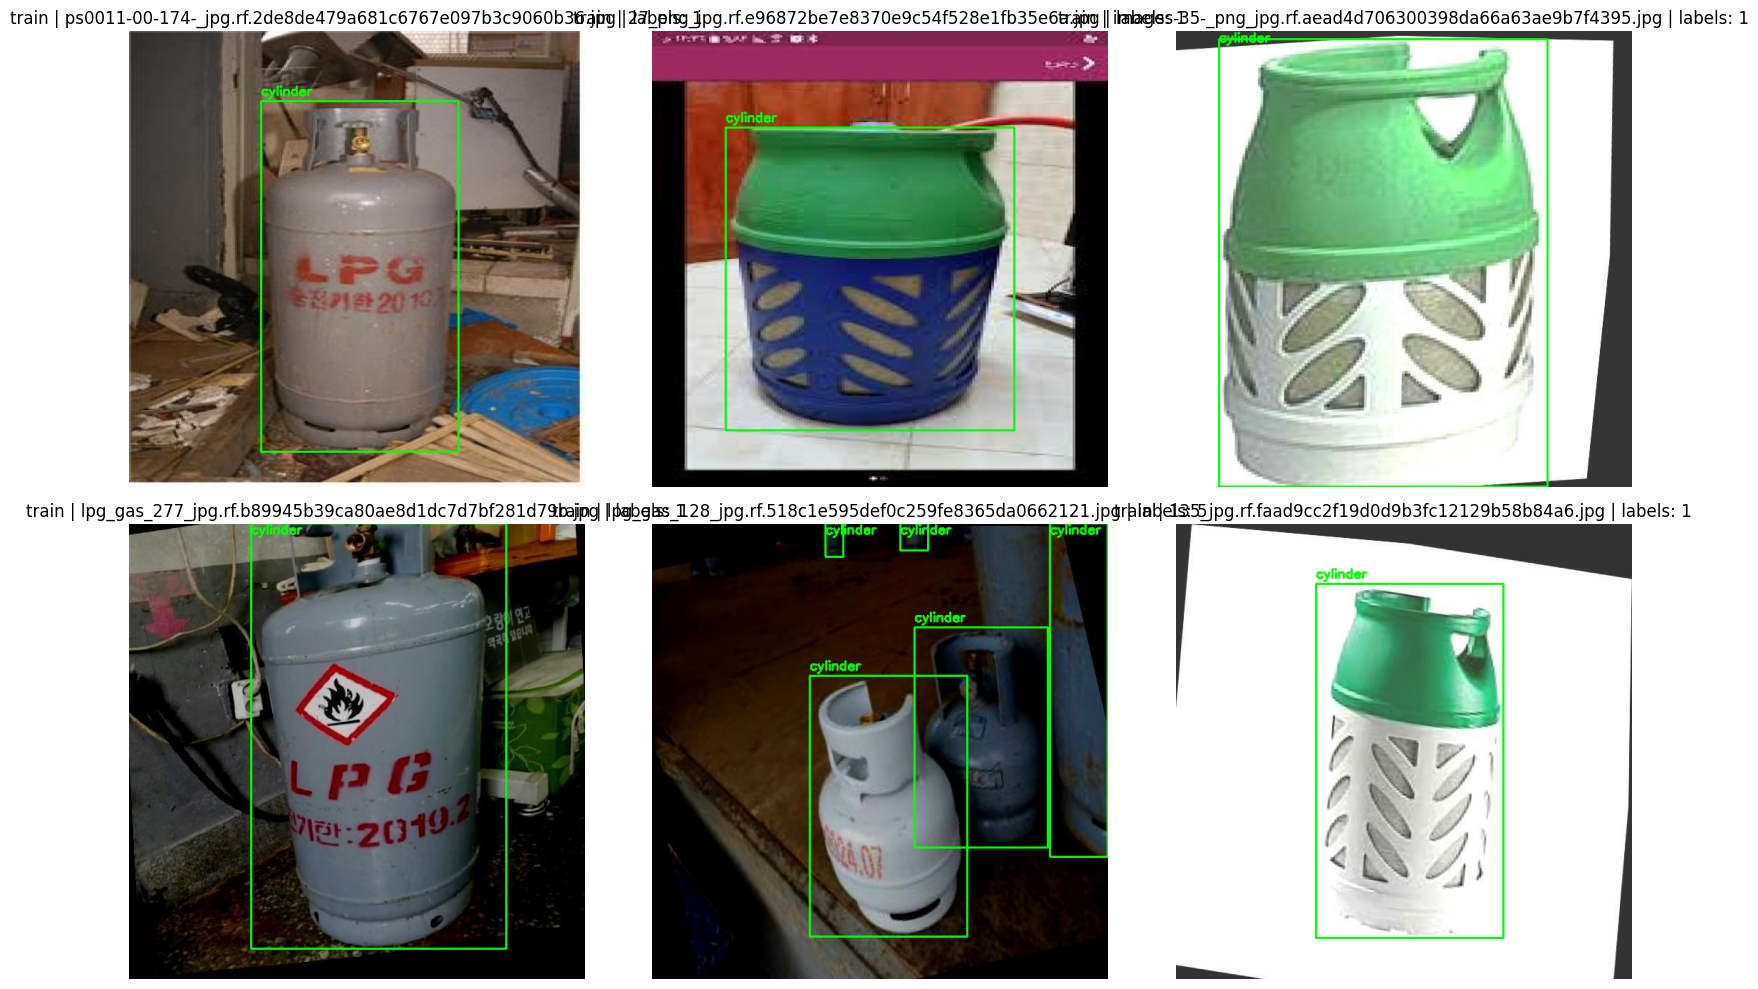

In [17]:
def mostrar_amostras(split=None, n=6):
    if split is None:
        split = SPLIT_TRAIN

    img_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    imagens = listar_imagens(img_dir)

    if len(imagens) == 0:
        print("Nenhuma imagem encontrada.")
        return

    amostras = random.sample(imagens, min(n, len(imagens)))

    cols = 3
    rows = (len(amostras) + cols - 1) // cols

    plt.figure(figsize=(16, 5 * rows))

    for i, img_path in enumerate(amostras):
        img_bgr = cv2.imread(str(img_path))

        if img_bgr is None:
            print("Erro ao ler:", img_path)
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        label_path = label_dir / f"{img_path.stem}.txt"
        labels = carregar_labels_yolo(label_path)

        img_draw = desenhar_bbox_yolo(img_rgb, labels)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_draw)
        plt.title(f"{split} | {img_path.name} | labels: {len(labels)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_amostras(SPLIT_TRAIN, n=6)

## Passo 18 — Conferir versão do Ultralytics

In [18]:
try:
    import ultralytics
    from ultralytics import YOLO

    print("Ultralytics instalado.")
    print("Versão:", ultralytics.__version__)
except ImportError as erro:
    raise ImportError(
        "O pacote ultralytics não está instalado. "
        "Execute a célula de instalação opcional e reinicie o kernel."
    ) from erro

Ultralytics instalado.
Versão: 8.4.58


## Passo 19 — Treinar o modelo YOLO com continuação automática

Esta célula é a célula oficial de treinamento.

Ela faz automaticamente:

- verifica se já existe treinamento anterior;
- se encontrar `last.pt`, continua a partir dos pesos salvos;
- se não encontrar pesos, inicia do modelo base;
- evita `resume=True` dentro do Jupyter para não gerar erro de multiprocessing;
- atualiza `BEST_MODEL_PATH`, `LAST_MODEL_PATH` e `RUN_DIR` para as próximas etapas.

> Observação: esta continuação é feita a partir dos pesos salvos em `last.pt`. Ela é mais estável no Jupyter remoto do que `resume=True`, mas não retoma exatamente o estado interno do otimizador.

In [21]:
# ============================================================
# Passo 19 — Modelo YOLO: usar peso oficial ou treinar
# Versão revisada com setups paramétricos, tempo e memória
# ============================================================
#
# Esta célula centraliza duas opções:
#
# 1. Usar peso oficial da GitHub Release
#    - baixa o peso treinado se ele não existir localmente;
#    - verifica SHA-256;
#    - configura BEST_MODEL_PATH para validação/inferência;
#    - permite usar o modelo sem treinar novamente.
#
# 2. Treinar ou continuar treinamento
#    - usa os parâmetros aplicados no Passo 7A;
#    - detecta execuções anteriores;
#    - se existir last.pt, continua a partir dele;
#    - se não existir, inicia do modelo base;
#    - registra tempo total, RAM e memória de GPU;
#    - salva um histórico em CSV.
# ============================================================

import os
import json
import time
import hashlib
import shutil
import urllib.request
import threading
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO

try:
    import psutil
    PSUTIL_OK = True
except ImportError:
    PSUTIL_OK = False
    print("Aviso: psutil não está instalado. A memória RAM não será monitorada.")
    print("Para instalar, use: pip install psutil")


# ------------------------------------------------------------
# Configurações do peso oficial
# ------------------------------------------------------------

YOLO_RELEASE_TAG = "v0.2.0-yolo-cylinders"

YOLO_OFFICIAL_WEIGHT_NAME = "yolo_cylinders_best.pt"
YOLO_OFFICIAL_SHA_NAME = "yolo_cylinders_best.sha256"

YOLO_OFFICIAL_WEIGHT_URL = (
    f"https://github.com/Ekamitani/BLAZE/releases/download/"
    f"{YOLO_RELEASE_TAG}/{YOLO_OFFICIAL_WEIGHT_NAME}"
)

YOLO_OFFICIAL_SHA_URL = (
    f"https://github.com/Ekamitani/BLAZE/releases/download/"
    f"{YOLO_RELEASE_TAG}/{YOLO_OFFICIAL_SHA_NAME}"
)

YOLO_OFFICIAL_WEIGHTS_DIR = (
    PROJECT_ROOT
    / "vision"
    / "results"
    / "yolo_cylinder_detector"
    / "weights"
)

YOLO_OFFICIAL_WEIGHT_PATH = YOLO_OFFICIAL_WEIGHTS_DIR / YOLO_OFFICIAL_WEIGHT_NAME
YOLO_OFFICIAL_SHA_PATH = YOLO_OFFICIAL_WEIGHTS_DIR / YOLO_OFFICIAL_SHA_NAME

STATUS_FILE_NAME = "blaze_training_status.json"
HISTORICO_TREINOS_YOLO_CSV = RESULTS_BASE_DIR / "historico_treinos_yolo.csv"

# Garante valores caso o Passo 7A não tenha sido executado.
YOLO_SETUP_ID_ATUAL = globals().get("YOLO_SETUP_ID_ATUAL", "manual")
YOLO_SETUP_NOME_ATUAL = globals().get("YOLO_SETUP_NOME_ATUAL", "Configuração manual")
YOLO_SETUP_DESCRICAO_ATUAL = globals().get("YOLO_SETUP_DESCRICAO_ATUAL", "")

CONTINUAR_TREINO_SE_EXISTIR = globals().get("CONTINUAR_TREINO_SE_EXISTIR", True)
FORCAR_TREINO_DO_ZERO = globals().get("FORCAR_TREINO_DO_ZERO", False)
CRIAR_NOVA_EXECUCAO_AO_CONTINUAR = globals().get("CRIAR_NOVA_EXECUCAO_AO_CONTINUAR", True)

YOLO_TRAIN_WORKERS = globals().get("YOLO_TRAIN_WORKERS", 0)
YOLO_TRAIN_CACHE = globals().get("YOLO_TRAIN_CACHE", False)
YOLO_TRAIN_PATIENCE = globals().get("YOLO_TRAIN_PATIENCE", 50)
YOLO_TRAIN_OPTIMIZER = globals().get("YOLO_TRAIN_OPTIMIZER", "auto")
YOLO_TRAIN_LR0 = globals().get("YOLO_TRAIN_LR0", "")
YOLO_TRAIN_SEED = globals().get("YOLO_TRAIN_SEED", 42)
YOLO_TRAIN_PLOTS = globals().get("YOLO_TRAIN_PLOTS", True)
YOLO_TRAIN_VERBOSE = globals().get("YOLO_TRAIN_VERBOSE", False)


# ------------------------------------------------------------
# Funções do peso oficial
# ------------------------------------------------------------

def baixar_arquivo(url, destino):
    destino = Path(destino)
    destino.parent.mkdir(parents=True, exist_ok=True)

    print("Baixando:")
    print(url)
    print("Destino:")
    print(destino)

    urllib.request.urlretrieve(url, destino)

    print("Download concluído.")


def calcular_sha256(caminho):
    caminho = Path(caminho)
    h = hashlib.sha256()

    with open(caminho, "rb") as f:
        for bloco in iter(lambda: f.read(1024 * 1024), b""):
            h.update(bloco)

    return h.hexdigest()


def ler_sha256_esperado(caminho_sha):
    texto = Path(caminho_sha).read_text(encoding="utf-8").strip()
    return texto.split()[0]


def usar_peso_oficial():
    """
    Baixa e configura o peso oficial da GitHub Release.
    """
    global BEST_MODEL_PATH, LAST_MODEL_PATH, RUN_DIR, WEIGHTS_DIR

    YOLO_OFFICIAL_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

    print("=== USO DO PESO OFICIAL ===")
    print("Release:", YOLO_RELEASE_TAG)
    print("Pasta local:", YOLO_OFFICIAL_WEIGHTS_DIR)
    print()

    if YOLO_OFFICIAL_WEIGHT_PATH.exists():
        print("Peso oficial já existe localmente:")
        print(YOLO_OFFICIAL_WEIGHT_PATH)
    else:
        baixar_arquivo(YOLO_OFFICIAL_WEIGHT_URL, YOLO_OFFICIAL_WEIGHT_PATH)

    print()

    if YOLO_OFFICIAL_SHA_PATH.exists():
        print("Arquivo SHA-256 já existe localmente:")
        print(YOLO_OFFICIAL_SHA_PATH)
    else:
        baixar_arquivo(YOLO_OFFICIAL_SHA_URL, YOLO_OFFICIAL_SHA_PATH)

    sha_esperado = ler_sha256_esperado(YOLO_OFFICIAL_SHA_PATH)
    sha_calculado = calcular_sha256(YOLO_OFFICIAL_WEIGHT_PATH)

    print("\n=== VERIFICAÇÃO SHA-256 ===")
    print("Esperado: ", sha_esperado)
    print("Calculado:", sha_calculado)

    if sha_esperado != sha_calculado:
        raise RuntimeError(
            "Falha na verificação SHA-256 do peso oficial.\n"
            "Apague o arquivo .pt local e rode esta opção novamente."
        )

    print("SHA-256 verificado com sucesso.")

    BEST_MODEL_PATH = YOLO_OFFICIAL_WEIGHT_PATH
    LAST_MODEL_PATH = YOLO_OFFICIAL_WEIGHT_PATH
    RUN_DIR = YOLO_OFFICIAL_WEIGHTS_DIR
    WEIGHTS_DIR = YOLO_OFFICIAL_WEIGHTS_DIR

    print("\n=== PESO OFICIAL CONFIGURADO ===")
    print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
    print("Existe?", BEST_MODEL_PATH.exists())
    print()
    print("Agora você pode seguir para validação, inferência em imagem, vídeo ou webcam.")
    print("Não é necessário treinar novamente.")


# ------------------------------------------------------------
# Funções de tempo e memória
# ------------------------------------------------------------

def _bytes_para_gb(x):
    try:
        return x / (1024 ** 3)
    except Exception:
        return np.nan


def _ram_process_gb():
    if not PSUTIL_OK:
        return np.nan
    try:
        return _bytes_para_gb(psutil.Process(os.getpid()).memory_info().rss)
    except Exception:
        return np.nan


def _ram_sistema_gb():
    if not PSUTIL_OK:
        return {"ram_sistema_total_gb": np.nan, "ram_sistema_disponivel_gb": np.nan, "ram_sistema_usada_gb": np.nan}
    try:
        vm = psutil.virtual_memory()
        return {
            "ram_sistema_total_gb": _bytes_para_gb(vm.total),
            "ram_sistema_disponivel_gb": _bytes_para_gb(vm.available),
            "ram_sistema_usada_gb": _bytes_para_gb(vm.used),
        }
    except Exception:
        return {"ram_sistema_total_gb": np.nan, "ram_sistema_disponivel_gb": np.nan, "ram_sistema_usada_gb": np.nan}


def _gpu_memoria_gb():
    if not torch.cuda.is_available():
        return {
            "gpu_disponivel": False,
            "gpu_nome": "",
            "gpu_mem_allocated_gb": np.nan,
            "gpu_mem_reserved_gb": np.nan,
            "gpu_mem_max_allocated_gb": np.nan,
            "gpu_mem_max_reserved_gb": np.nan,
        }

    idx = torch.cuda.current_device()
    return {
        "gpu_disponivel": True,
        "gpu_nome": torch.cuda.get_device_name(idx),
        "gpu_mem_allocated_gb": _bytes_para_gb(torch.cuda.memory_allocated(idx)),
        "gpu_mem_reserved_gb": _bytes_para_gb(torch.cuda.memory_reserved(idx)),
        "gpu_mem_max_allocated_gb": _bytes_para_gb(torch.cuda.max_memory_allocated(idx)),
        "gpu_mem_max_reserved_gb": _bytes_para_gb(torch.cuda.max_memory_reserved(idx)),
    }


class MonitorMemoria:
    """
    Monitora pico de RAM do processo e pico de RAM do sistema durante o treino.
    """
    def __init__(self, intervalo_s=1.0):
        self.intervalo_s = intervalo_s
        self.rodando = False
        self.thread = None
        self.ram_processo_pico_gb = np.nan
        self.ram_sistema_usada_pico_gb = np.nan
        self.amostras = 0

    def _loop(self):
        while self.rodando:
            proc = _ram_process_gb()
            sist = _ram_sistema_gb().get("ram_sistema_usada_gb", np.nan)

            if not np.isnan(proc):
                if np.isnan(self.ram_processo_pico_gb) or proc > self.ram_processo_pico_gb:
                    self.ram_processo_pico_gb = proc

            if not np.isnan(sist):
                if np.isnan(self.ram_sistema_usada_pico_gb) or sist > self.ram_sistema_usada_pico_gb:
                    self.ram_sistema_usada_pico_gb = sist

            self.amostras += 1
            time.sleep(self.intervalo_s)

    def iniciar(self):
        self.rodando = True
        self.thread = threading.Thread(target=self._loop, daemon=True)
        self.thread.start()

    def parar(self):
        self.rodando = False
        if self.thread is not None:
            self.thread.join(timeout=2)


def _safe_csv_read(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except Exception:
        return pd.DataFrame()


def _safe_csv_append(path, row):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    nova = pd.DataFrame([row])
    atual = _safe_csv_read(path)
    if len(atual) > 0:
        out = pd.concat([atual, nova], ignore_index=True)
    else:
        out = nova
    tmp = path.with_suffix(path.suffix + ".tmp")
    out.to_csv(tmp, index=False)
    tmp.replace(path)
    return out


def _extrair_metricas_finais_results_csv(run_dir):
    results_csv = Path(run_dir) / "results.csv"
    metricas = {
        "results_csv": str(results_csv),
        "results_csv_existe": results_csv.exists(),
        "epochs_registradas_results_csv": 0,
        "train_box_loss_final": np.nan,
        "train_cls_loss_final": np.nan,
        "train_dfl_loss_final": np.nan,
        "val_box_loss_final": np.nan,
        "val_cls_loss_final": np.nan,
        "val_dfl_loss_final": np.nan,
        "precision_final": np.nan,
        "recall_final": np.nan,
        "mAP50_final": np.nan,
        "mAP50_95_final": np.nan,
    }

    df = _safe_csv_read(results_csv)
    metricas["epochs_registradas_results_csv"] = len(df)

    if len(df) == 0:
        return metricas

    r = df.iloc[-1].to_dict()

    def get_col(*nomes):
        for nome in nomes:
            if nome in r:
                return r[nome]
        return np.nan

    metricas.update({
        "train_box_loss_final": get_col("train/box_loss"),
        "train_cls_loss_final": get_col("train/cls_loss"),
        "train_dfl_loss_final": get_col("train/dfl_loss"),
        "val_box_loss_final": get_col("val/box_loss"),
        "val_cls_loss_final": get_col("val/cls_loss"),
        "val_dfl_loss_final": get_col("val/dfl_loss"),
        "precision_final": get_col("metrics/precision(B)", "precision(B)"),
        "recall_final": get_col("metrics/recall(B)", "recall(B)"),
        "mAP50_final": get_col("metrics/mAP50(B)", "mAP50(B)"),
        "mAP50_95_final": get_col("metrics/mAP50-95(B)", "mAP50-95(B)"),
    })

    return metricas


def _hash_params_treino_atual():
    params = {
        "setup_id": globals().get("YOLO_SETUP_ID_ATUAL", "manual"),
        "modelo_base": MODELO_BASE,
        "run_name": RUN_NAME,
        "epochs": EPOCHS,
        "imgsz": IMGSZ,
        "batch": BATCH,
        "conf": CONF,
        "iou": IOU,
        "device_yolo": DEVICE_YOLO,
        "continuar_treino_se_existir": CONTINUAR_TREINO_SE_EXISTIR,
        "forcar_treino_do_zero": FORCAR_TREINO_DO_ZERO,
        "criar_nova_execucao_ao_continuar": CRIAR_NOVA_EXECUCAO_AO_CONTINUAR,
        "workers": YOLO_TRAIN_WORKERS,
        "cache": YOLO_TRAIN_CACHE,
        "patience": YOLO_TRAIN_PATIENCE,
        "optimizer": YOLO_TRAIN_OPTIMIZER,
        "lr0": YOLO_TRAIN_LR0,
        "seed": YOLO_TRAIN_SEED,
    }
    texto = json.dumps(params, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(texto.encode("utf-8")).hexdigest()[:12]


# ------------------------------------------------------------
# Funções de treinamento/continuação
# ------------------------------------------------------------

def contar_epocas_no_results_csv(run_dir):
    df = _safe_csv_read(Path(run_dir) / "results.csv")
    return len(df)


def ler_status_blaze(run_dir):
    status_path = Path(run_dir) / STATUS_FILE_NAME

    if not status_path.exists():
        return {
            "epochs_before_this_run": 0,
            "target_total_epochs": EPOCHS,
            "source_checkpoint": None,
        }

    try:
        with open(status_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {
            "epochs_before_this_run": 0,
            "target_total_epochs": EPOCHS,
            "source_checkpoint": None,
        }


def salvar_status_blaze(run_dir, status):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    status_path = run_dir / STATUS_FILE_NAME
    with open(status_path, "w", encoding="utf-8") as f:
        json.dump(status, f, indent=4, ensure_ascii=False)


def obter_info_execucao(run_dir):
    run_dir = Path(run_dir)
    weights_dir = run_dir / "weights"
    best_path = weights_dir / "best.pt"
    last_path = weights_dir / "last.pt"

    status = ler_status_blaze(run_dir)
    epocas_nesta_execucao = contar_epocas_no_results_csv(run_dir)
    epocas_anteriores = int(status.get("epochs_before_this_run", 0))
    epocas_totais_estimadas = epocas_anteriores + epocas_nesta_execucao

    if last_path.exists():
        mtime = last_path.stat().st_mtime
    elif best_path.exists():
        mtime = best_path.stat().st_mtime
    elif run_dir.exists():
        mtime = run_dir.stat().st_mtime
    else:
        mtime = 0

    return {
        "run_dir": run_dir,
        "weights_dir": weights_dir,
        "best_path": best_path,
        "last_path": last_path,
        "status": status,
        "epocas_nesta_execucao": epocas_nesta_execucao,
        "epocas_anteriores": epocas_anteriores,
        "epocas_totais_estimadas": epocas_totais_estimadas,
        "mtime": mtime,
        "tem_best": best_path.exists(),
        "tem_last": last_path.exists(),
    }


def encontrar_execucoes_do_treino():
    train_project_dir = Path(TRAIN_PROJECT_DIR)

    if not train_project_dir.exists():
        return []

    execucoes = []

    for item in train_project_dir.iterdir():
        if item.is_dir() and item.name.startswith(RUN_NAME):
            info = obter_info_execucao(item)
            if info["tem_last"] or info["tem_best"]:
                execucoes.append(info)

    execucoes = sorted(
        execucoes,
        key=lambda x: (x["epocas_totais_estimadas"], x["mtime"]),
        reverse=True,
    )

    return execucoes


def mostrar_resumo_execucoes(execucoes):
    if not execucoes:
        print("Nenhuma execução anterior encontrada.")
        return

    print("Execuções anteriores encontradas:\n")

    for i, info in enumerate(execucoes, start=1):
        print(f"[{i}] {info['run_dir'].name}")
        print(f"    Épocas nesta execução: {info['epocas_nesta_execucao']}")
        print(f"    Épocas anteriores:      {info['epocas_anteriores']}")
        print(f"    Total estimado:         {info['epocas_totais_estimadas']}/{EPOCHS}")
        print(f"    best.pt:                {info['tem_best']}")
        print(f"    last.pt:                {info['tem_last']}")
        print()


def treinar_ou_continuar():
    """
    Executa treinamento novo ou continuação automática com registro de tempo e memória.
    """
    global BEST_MODEL_PATH, LAST_MODEL_PATH, RUN_DIR, WEIGHTS_DIR

    print("=== CONFIGURAÇÃO DO TREINAMENTO ===")
    print("Setup ID:", globals().get("YOLO_SETUP_ID_ATUAL", "manual"))
    print("Setup nome:", globals().get("YOLO_SETUP_NOME_ATUAL", ""))
    print("Hash params:", _hash_params_treino_atual())
    print("Modelo base:", MODELO_BASE)
    print("Dataset YAML:", DATA_YAML_LOCAL)
    print("Train project dir:", TRAIN_PROJECT_DIR)
    print("Run base:", RUN_NAME)
    print("Epochs desejadas:", EPOCHS)
    print("Image size:", IMGSZ)
    print("Batch:", BATCH)
    print("Conf validação/inferência:", CONF)
    print("IoU validação/inferência:", IOU)
    print("DEVICE_YOLO:", DEVICE_YOLO)
    print("Workers:", YOLO_TRAIN_WORKERS)
    print("Cache:", YOLO_TRAIN_CACHE)
    print("Patience:", YOLO_TRAIN_PATIENCE)
    print("Optimizer:", YOLO_TRAIN_OPTIMIZER)
    print("lr0:", YOLO_TRAIN_LR0)
    print("Seed:", YOLO_TRAIN_SEED)
    print()

    if not Path(DATA_YAML_LOCAL).exists():
        raise FileNotFoundError(f"Arquivo data.yaml não encontrado: {DATA_YAML_LOCAL}")

    if torch.cuda.is_available():
        print("CUDA disponível.")
        print("GPU visível para o notebook:", torch.cuda.get_device_name(0))
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    else:
        print("CUDA não disponível. O treino será feito em CPU.")

    print()

    execucoes = encontrar_execucoes_do_treino()
    mostrar_resumo_execucoes(execucoes)
    execucao_referencia = execucoes[0] if execucoes else None

    if FORCAR_TREINO_DO_ZERO:
        modo_treino = "novo"
        checkpoint_inicial = MODELO_BASE
        epocas_ja_feitas = 0
        epocas_para_treinar = EPOCHS

    elif (
        CONTINUAR_TREINO_SE_EXISTIR
        and execucao_referencia is not None
        and execucao_referencia["tem_last"]
    ):
        epocas_ja_feitas = execucao_referencia["epocas_totais_estimadas"]

        if epocas_ja_feitas >= EPOCHS:
            modo_treino = "pular"
            checkpoint_inicial = execucao_referencia["last_path"]
            epocas_para_treinar = 0
        else:
            modo_treino = "continuar"
            checkpoint_inicial = execucao_referencia["last_path"]
            epocas_para_treinar = max(EPOCHS - epocas_ja_feitas, 1)

    else:
        modo_treino = "novo"
        checkpoint_inicial = MODELO_BASE
        epocas_ja_feitas = 0
        epocas_para_treinar = EPOCHS

    print("=== DECISÃO AUTOMÁTICA ===")
    print("Modo:", modo_treino)
    print("Checkpoint/modelo inicial:", checkpoint_inicial)
    print("Épocas já feitas:", epocas_ja_feitas)
    print("Épocas que serão treinadas agora:", epocas_para_treinar)
    print()

    data_hora_inicio = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    data_hora_fim = ""
    erro_treino = ""
    tempo_treino_s = 0.0

    ram_inicio_gb = _ram_process_gb()
    ram_sistema_inicio = _ram_sistema_gb()
    gpu_inicio = _gpu_memoria_gb()

    monitor = MonitorMemoria(intervalo_s=1.0)

    if modo_treino == "pular":
        print("O treinamento já parece ter atingido o total desejado de épocas.")
        print("Nenhum novo treinamento será iniciado.")

        RUN_DIR = execucao_referencia["run_dir"]
        WEIGHTS_DIR = execucao_referencia["weights_dir"]
        BEST_MODEL_PATH = execucao_referencia["best_path"]
        LAST_MODEL_PATH = execucao_referencia["last_path"]
        data_hora_fim = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    else:
        if modo_treino == "novo":
            run_name_atual = RUN_NAME
            epochs_before_this_run = 0

        elif modo_treino == "continuar":
            if CRIAR_NOVA_EXECUCAO_AO_CONTINUAR:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                run_name_atual = f"{RUN_NAME}_cont_{timestamp}"
            else:
                run_name_atual = RUN_NAME

            epochs_before_this_run = epocas_ja_feitas

        RUN_DIR = Path(TRAIN_PROJECT_DIR) / run_name_atual
        WEIGHTS_DIR = RUN_DIR / "weights"
        BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
        LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

        status_inicial = {
            "project": "BLAZE",
            "module": "vision/cylinders_detect/YOLO",
            "setup_id": globals().get("YOLO_SETUP_ID_ATUAL", "manual"),
            "setup_nome": globals().get("YOLO_SETUP_NOME_ATUAL", ""),
            "params_hash": _hash_params_treino_atual(),
            "run_name": run_name_atual,
            "mode": modo_treino,
            "source_checkpoint": str(checkpoint_inicial),
            "epochs_before_this_run": int(epochs_before_this_run),
            "epochs_requested_this_run": int(epocas_para_treinar),
            "target_total_epochs": int(EPOCHS),
            "data_yaml": str(DATA_YAML_LOCAL),
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }

        salvar_status_blaze(RUN_DIR, status_inicial)

        print("Iniciando treinamento...")
        print("Run atual:", run_name_atual)
        print("Pasta da execução:", RUN_DIR)
        print()

        train_kwargs = dict(
            data=str(DATA_YAML_LOCAL),
            epochs=int(epocas_para_treinar),
            imgsz=int(IMGSZ),
            batch=int(BATCH),
            device=DEVICE_YOLO,
            workers=int(YOLO_TRAIN_WORKERS),
            cache=bool(YOLO_TRAIN_CACHE),
            patience=int(YOLO_TRAIN_PATIENCE),
            optimizer=str(YOLO_TRAIN_OPTIMIZER),
            seed=int(YOLO_TRAIN_SEED),
            project=str(TRAIN_PROJECT_DIR),
            name=run_name_atual,
            exist_ok=True,
            plots=bool(YOLO_TRAIN_PLOTS),
            verbose=bool(YOLO_TRAIN_VERBOSE),
        )

        # Só passa lr0 se o usuário informou valor.
        if not (isinstance(YOLO_TRAIN_LR0, str) and YOLO_TRAIN_LR0.strip() == ""):
            try:
                train_kwargs["lr0"] = float(YOLO_TRAIN_LR0)
            except Exception:
                print("Aviso: lr0 inválido. O padrão do Ultralytics será usado.")

        model = YOLO(str(checkpoint_inicial))

        t0 = time.perf_counter()
        monitor.iniciar()

        try:
            results = model.train(**train_kwargs)
        except Exception as e:
            erro_treino = str(e)
            raise
        finally:
            monitor.parar()
            tempo_treino_s = time.perf_counter() - t0
            data_hora_fim = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        status_final = status_inicial.copy()
        status_final["finished_at"] = datetime.now().isoformat(timespec="seconds")
        status_final["epochs_completed_this_run"] = contar_epocas_no_results_csv(RUN_DIR)
        status_final["estimated_total_epochs_completed"] = (
            status_final["epochs_before_this_run"]
            + status_final["epochs_completed_this_run"]
        )
        status_final["best_model_path"] = str(BEST_MODEL_PATH)
        status_final["last_model_path"] = str(LAST_MODEL_PATH)
        status_final["tempo_treino_s"] = tempo_treino_s
        status_final["erro_treino"] = erro_treino

        salvar_status_blaze(RUN_DIR, status_final)

        # Copia o best.pt para a pasta padronizada de pesos, se existir.
        peso_padrao_dir = RESULTS_BASE_DIR / "weights"
        peso_padrao_dir.mkdir(parents=True, exist_ok=True)
        peso_padrao = peso_padrao_dir / "yolo_cylinders_best.pt"
        if Path(BEST_MODEL_PATH).exists():
            shutil.copy2(BEST_MODEL_PATH, peso_padrao)
            print("Cópia do melhor peso salva em:")
            print(peso_padrao)

        print("Treinamento finalizado ou interrompido após a execução da célula.")

    ram_fim_gb = _ram_process_gb()
    ram_sistema_fim = _ram_sistema_gb()
    gpu_fim = _gpu_memoria_gb()
    metricas_results = _extrair_metricas_finais_results_csv(RUN_DIR)

    linha_hist = {
        "data_hora_inicio": data_hora_inicio,
        "data_hora_fim": data_hora_fim,
        "setup_id": globals().get("YOLO_SETUP_ID_ATUAL", "manual"),
        "setup_nome": globals().get("YOLO_SETUP_NOME_ATUAL", ""),
        "params_hash": _hash_params_treino_atual(),
        "modo_treino": modo_treino,
        "run_name": Path(RUN_DIR).name,
        "modelo_base": str(MODELO_BASE),
        "checkpoint_inicial": str(checkpoint_inicial),
        "dataset_dir": str(DATASET_DIR),
        "data_yaml": str(DATA_YAML_LOCAL),
        "epochs_alvo_total": int(EPOCHS),
        "epochs_ja_feitas_antes": int(epocas_ja_feitas),
        "epochs_solicitadas_nesta_execucao": int(epocas_para_treinar),
        "epochs_registradas_nesta_execucao": int(contar_epocas_no_results_csv(RUN_DIR)),
        "imgsz": int(IMGSZ),
        "batch": int(BATCH),
        "conf": float(CONF),
        "iou": float(IOU),
        "device_yolo": str(DEVICE_YOLO),
        "workers": int(YOLO_TRAIN_WORKERS),
        "cache": bool(YOLO_TRAIN_CACHE),
        "patience": int(YOLO_TRAIN_PATIENCE),
        "optimizer": str(YOLO_TRAIN_OPTIMIZER),
        "lr0": YOLO_TRAIN_LR0,
        "seed": int(YOLO_TRAIN_SEED),
        "tempo_treino_s": float(tempo_treino_s),
        "tempo_treino_min": float(tempo_treino_s / 60),
        "tempo_treino_h": float(tempo_treino_s / 3600),
        "ram_processo_inicio_gb": ram_inicio_gb,
        "ram_processo_fim_gb": ram_fim_gb,
        "ram_processo_pico_gb": monitor.ram_processo_pico_gb,
        "ram_sistema_total_gb": ram_sistema_fim.get("ram_sistema_total_gb", np.nan),
        "ram_sistema_usada_inicio_gb": ram_sistema_inicio.get("ram_sistema_usada_gb", np.nan),
        "ram_sistema_usada_fim_gb": ram_sistema_fim.get("ram_sistema_usada_gb", np.nan),
        "ram_sistema_usada_pico_gb": monitor.ram_sistema_usada_pico_gb,
        "gpu_disponivel": gpu_fim.get("gpu_disponivel", False),
        "gpu_nome": gpu_fim.get("gpu_nome", ""),
        "gpu_mem_inicio_allocated_gb": gpu_inicio.get("gpu_mem_allocated_gb", np.nan),
        "gpu_mem_inicio_reserved_gb": gpu_inicio.get("gpu_mem_reserved_gb", np.nan),
        "gpu_mem_fim_allocated_gb": gpu_fim.get("gpu_mem_allocated_gb", np.nan),
        "gpu_mem_fim_reserved_gb": gpu_fim.get("gpu_mem_reserved_gb", np.nan),
        "gpu_mem_pico_allocated_gb": gpu_fim.get("gpu_mem_max_allocated_gb", np.nan),
        "gpu_mem_pico_reserved_gb": gpu_fim.get("gpu_mem_max_reserved_gb", np.nan),
        "run_dir": str(RUN_DIR),
        "best_model_path": str(BEST_MODEL_PATH),
        "last_model_path": str(LAST_MODEL_PATH),
        "python": platform.python_version(),
        "sistema": platform.system(),
        "processador": platform.processor(),
        "erro_treino": erro_treino,
    }
    linha_hist.update(metricas_results)

    df_hist = _safe_csv_append(HISTORICO_TREINOS_YOLO_CSV, linha_hist)

    print("\n=== MODELOS ATUAIS PARA AS PRÓXIMAS ETAPAS ===")
    print("RUN_DIR:", RUN_DIR)
    print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
    print("LAST_MODEL_PATH:", LAST_MODEL_PATH)
    print("best.pt existe?", Path(BEST_MODEL_PATH).exists())
    print("last.pt existe?", Path(LAST_MODEL_PATH).exists())

    print("\n=== TEMPO E MEMÓRIA ===")
    print(f"Tempo de treinamento: {tempo_treino_s:.2f} s ({tempo_treino_s/60:.2f} min)")
    print(f"RAM processo início: {ram_inicio_gb:.2f} GB")
    print(f"RAM processo fim:    {ram_fim_gb:.2f} GB")
    print(f"RAM processo pico:   {monitor.ram_processo_pico_gb:.2f} GB")
    print(f"RAM sistema pico:    {monitor.ram_sistema_usada_pico_gb:.2f} GB")

    if gpu_fim.get("gpu_disponivel", False):
        print("GPU:", gpu_fim.get("gpu_nome", ""))
        print(f"GPU pico allocated: {gpu_fim.get('gpu_mem_max_allocated_gb', np.nan):.2f} GB")
        print(f"GPU pico reserved:  {gpu_fim.get('gpu_mem_max_reserved_gb', np.nan):.2f} GB")
    else:
        print("GPU CUDA não disponível ou não utilizada.")

    print("\nHistórico de treino YOLO salvo em:")
    print(HISTORICO_TREINOS_YOLO_CSV)

    display(pd.DataFrame([linha_hist]))

    if Path(BEST_MODEL_PATH).exists():
        print("\nUse BEST_MODEL_PATH nas próximas células de validação, inferência e webcam.")
    elif Path(LAST_MODEL_PATH).exists():
        print("\nAtenção: best.pt não foi encontrado, mas last.pt existe.")
        print("Você pode usar last.pt temporariamente para inferência ou continuar o treino.")
    else:
        print("\nAtenção: nenhum peso foi encontrado ao final.")


# ------------------------------------------------------------
# Interface de seleção
# ------------------------------------------------------------

modo_modelo_widget = widgets.RadioButtons(
    options=[
        ("Usar peso oficial da Release", "peso_oficial"),
        ("Treinar ou continuar treinamento", "treinar"),
    ],
    value="peso_oficial",
    description="Opção:",
    layout=widgets.Layout(width="480px"),
)

botao_executar_passo_19 = widgets.Button(
    description="Executar opção selecionada",
    button_style="success",
    layout=widgets.Layout(width="260px"),
)

saida_passo_19 = widgets.Output()


def executar_passo_19(_=None):
    with saida_passo_19:
        clear_output(wait=True)
        opcao = modo_modelo_widget.value

        if opcao == "peso_oficial":
            usar_peso_oficial()
        elif opcao == "treinar":
            treinar_ou_continuar()
        else:
            print("Opção inválida.")


botao_executar_passo_19.on_click(executar_passo_19)

display(modo_modelo_widget)
display(botao_executar_passo_19)
display(saida_passo_19)

print("Selecione uma opção para o Passo 19.")
print()
print("Setup atual:", globals().get("YOLO_SETUP_ID_ATUAL", "manual"), "|", globals().get("YOLO_SETUP_NOME_ATUAL", ""))
print("RUN_NAME:", RUN_NAME)
print("EPOCHS:", EPOCHS, "| IMGSZ:", IMGSZ, "| BATCH:", BATCH, "| DEVICE_YOLO:", DEVICE_YOLO)
print()
print("Recomendado para usuário externo:")
print("- Usar peso oficial da Release")
print()
print("Recomendado para novo treinamento ou ajuste fino:")
print("- Treinar ou continuar treinamento")
print()
print("Antes de treinar, configure/aplique o setup no Passo 7A.")


RadioButtons(description='Opção:', layout=Layout(width='420px'), options=(('Usar peso oficial da Release', 'pe…

Button(button_style='success', description='Executar opção selecionada', layout=Layout(width='260px'), style=B…

Output()

Selecione uma opção para o Passo 19.

Recomendado para usuário externo:
- Usar peso oficial da Release

Recomendado para novo treinamento ou ajuste fino:
- Treinar ou continuar treinamento


## Passo 20 — Verificar pesos salvos

O arquivo mais importante é `best.pt`.

In [22]:
print("Pasta da execução:")
print(RUN_DIR)
print("Existe?", RUN_DIR.exists())

print("\nPasta de pesos:")
print(WEIGHTS_DIR)
print("Existe?", WEIGHTS_DIR.exists())

if WEIGHTS_DIR.exists():
    print("\nArquivos encontrados:")
    for p in sorted(WEIGHTS_DIR.iterdir()):
        print("-", p.name)
else:
    print("\nPasta weights ainda não foi criada.")

print("\nbest.pt existe?", BEST_MODEL_PATH.exists())
print("last.pt existe?", LAST_MODEL_PATH.exists())

Pasta da execução:
vision/results/yolo_cylinder_detector/weights
Existe? True

Pasta de pesos:
vision/results/yolo_cylinder_detector/weights
Existe? True

Arquivos encontrados:
- results.csv
- yolo_cylinders_best.pt
- yolo_cylinders_best.sha256

best.pt existe? True
last.pt existe? True


## Passo 21 — Validar o modelo treinado

Avalia o `best.pt` no conjunto de validação.

A saída foi compactada para evitar listas extensas no notebook. O objeto completo de métricas continua disponível na variável `metrics`.

In [23]:
# ============================================================
# Passo 21 — Validação com saída compacta e tempo registrado
# ============================================================

import io
import contextlib
import time
import pandas as pd
from ultralytics import YOLO

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError("O arquivo best.pt ainda não existe. Execute o treinamento ou carregue o peso oficial antes da validação.")

MOSTRAR_LOG_VALIDACAO = False

model_trained = YOLO(str(BEST_MODEL_PATH))

print("Validando modelo:")
print(BEST_MODEL_PATH)

YOLO_VAL_TIME_S = None

val_t0 = time.perf_counter()

if MOSTRAR_LOG_VALIDACAO:
    metrics = model_trained.val(
        data=str(DATA_YAML_LOCAL),
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        project=str(VAL_PROJECT_DIR),
        name=RUN_NAME + "_val",
        exist_ok=True,
        plots=True,
        verbose=False,
    )
else:
    log_buffer = io.StringIO()
    try:
        with contextlib.redirect_stdout(log_buffer), contextlib.redirect_stderr(log_buffer):
            metrics = model_trained.val(
                data=str(DATA_YAML_LOCAL),
                imgsz=IMGSZ,
                batch=BATCH,
                device=DEVICE,
                project=str(VAL_PROJECT_DIR),
                name=RUN_NAME + "_val",
                exist_ok=True,
                plots=True,
                verbose=False,
            )
    except Exception:
        print("A validação falhou. Últimas linhas do log capturado:")
        print(log_buffer.getvalue()[-4000:])
        raise

YOLO_VAL_TIME_S = time.perf_counter() - val_t0


def _safe_metric(obj, path):
    """Obtém métrica por caminho de atributos, sem quebrar se ela não existir."""
    atual = obj
    for parte in path.split("."):
        atual = getattr(atual, parte, None)
        if atual is None:
            return None
    try:
        return float(atual)
    except Exception:
        return atual

resumo_metricas = {
    "precision(B)": _safe_metric(metrics, "box.mp"),
    "recall(B)": _safe_metric(metrics, "box.mr"),
    "mAP50(B)": _safe_metric(metrics, "box.map50"),
    "mAP50-95(B)": _safe_metric(metrics, "box.map"),
}

# Algumas versões do Ultralytics também fornecem results_dict.
if hasattr(metrics, "results_dict") and isinstance(metrics.results_dict, dict):
    for chave, valor in metrics.results_dict.items():
        if chave not in resumo_metricas:
            try:
                resumo_metricas[chave] = float(valor)
            except Exception:
                resumo_metricas[chave] = valor

# Calcula F1 aproximado a partir de precision/recall globais.
p_det = resumo_metricas.get("precision(B)")
r_det = resumo_metricas.get("recall(B)")
if p_det is not None and r_det is not None and (p_det + r_det) > 0:
    resumo_metricas["F1(B)"] = 2 * p_det * r_det / (p_det + r_det)

# Speed do Ultralytics costuma vir em ms/imagem.
if hasattr(metrics, "speed") and isinstance(metrics.speed, dict):
    for chave, valor in metrics.speed.items():
        try:
            resumo_metricas[f"speed_{chave}_ms_img"] = float(valor)
        except Exception:
            resumo_metricas[f"speed_{chave}_ms_img"] = valor

resumo_metricas["tempo_validacao_total_s"] = YOLO_VAL_TIME_S

print("\nValidação concluída.")
print("Pasta de saída:", VAL_PROJECT_DIR / (RUN_NAME + "_val"))
print(f"Tempo total de validação: {YOLO_VAL_TIME_S:.2f} s")

# Mostra somente uma tabela curta, evitando print(metrics), que pode ser extenso.
df_metricas = pd.DataFrame(
    [{k: v for k, v in resumo_metricas.items() if v is not None}]
)
display(df_metricas)

print("\nObjeto completo disponível na variável: metrics")


Validando modelo:
vision/results/yolo_cylinder_detector/weights/yolo_cylinders_best.pt
Ultralytics 8.4.58 🚀 Python-3.13.9 torch-2.12.0+cu130 CPU (12th Gen Intel Core i7-12650H)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 283.6±119.0 MB/s, size: 47.2 KB)
                   all       1434       4862      0.901      0.829      0.907      0.667
Speed: 0.9ms preprocess, 48.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to vision/results/yolo_cylinder_detector/runs/val/yolov8n_cilindros_blaze_v1_val

Validação concluída.
Pasta de saída: vision/results/yolo_cylinder_detector/runs/val/yolov8n_cilindros_blaze_v1_val
Tempo total de validação: 77.83 s


,precision(B),recall(B),mAP50(B),mAP50-95(B),metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness,F1(B),speed_preprocess_ms_img,speed_inference_ms_img,speed_loss_ms_img,speed_postprocess_ms_img,tempo_validacao_total_s
0,0.901171,0.829494,0.906961,0.666735,0.901171,0.829494,0.906961,0.666735,0.666735,0.863848,0.875885,48.493851,0.000108,0.462248,77.826884



Objeto completo disponível na variável: metrics


## Passo 22 — Inferência nas imagens de teste

Aplica o modelo treinado nas imagens do split de teste, se existir. Caso não exista `test`, usa validação.

In [24]:
# ============================================================
# Passo 22 — Inferência nas imagens de teste com tempo registrado
# ============================================================

import time

if SPLIT_TEST is not None:
    SOURCE_TEST = DATASET_DIR / SPLIT_TEST / "images"
else:
    SOURCE_TEST = DATASET_DIR / SPLIT_VAL / "images"

PRED_NAME = RUN_NAME + "_pred_dataset"
PRED_DIR = PRED_PROJECT_DIR / PRED_NAME

REFAZER_INFERENCIA_DATASET = False

print("Fonte de imagens:")
print(SOURCE_TEST)
print("Existe?", SOURCE_TEST.exists())

if not SOURCE_TEST.exists():
    raise FileNotFoundError(f"Pasta de imagens não encontrada: {SOURCE_TEST}")

predicoes_existentes = []
if PRED_DIR.exists():
    predicoes_existentes = listar_imagens(PRED_DIR)

YOLO_PRED_TIME_S = None
YOLO_PRED_N_IMAGES = len(listar_imagens(SOURCE_TEST))

if predicoes_existentes and not REFAZER_INFERENCIA_DATASET:
    print("Predições já encontradas. A inferência foi pulada para preservar os arquivos existentes.")
    print("Pasta:", PRED_DIR)
    print("Quantidade de imagens:", len(predicoes_existentes))
    print("\nPara refazer e medir tempo novamente, altere REFAZER_INFERENCIA_DATASET = True.")
else:
    pred_t0 = time.perf_counter()

    results_pred = model_trained.predict(
        source=str(SOURCE_TEST),
        imgsz=IMGSZ,
        conf=CONF,
        iou=IOU,
        device=DEVICE,
        save=True,
        project=str(PRED_PROJECT_DIR),
        name=PRED_NAME,
        exist_ok=True,
        verbose=False,
    )

    YOLO_PRED_TIME_S = time.perf_counter() - pred_t0

    print("Inferência concluída.")
    print("Resultados salvos em:")
    print(PRED_DIR)
    print(f"Imagens processadas: {YOLO_PRED_N_IMAGES}")
    print(f"Tempo total de inferência: {YOLO_PRED_TIME_S:.2f} s")
    if YOLO_PRED_N_IMAGES > 0:
        print(f"Tempo por imagem: {YOLO_PRED_TIME_S / YOLO_PRED_N_IMAGES:.4f} s/imagem")


Fonte de imagens:
vision/datasets/cylinders/CylinDeRS-1/test/images
Existe? True
Predições já encontradas. A inferência foi pulada para preservar os arquivos existentes.
Pasta: vision/results/yolo_cylinder_detector/runs/predict/yolov8n_cilindros_blaze_v1_pred_dataset
Quantidade de imagens: 711

Para refazer e medir tempo novamente, altere REFAZER_INFERENCIA_DATASET = True.


## Passo 23 — Visualizar predições salvas do dataset

Mostra imagens já processadas no Passo 22.

Use o botão para sortear outras predições salvas, sem precisar refazer a inferência.

In [25]:
# ============================================================
# Passo 23 — Visualizador interativo de predições salvas
# ============================================================

import random
import ipywidgets as widgets
from IPython.display import display, clear_output

pred_images = listar_imagens(PRED_DIR)

print("Pasta de predições:")
print(PRED_DIR)
print("Quantidade de imagens encontradas:", len(pred_images))

if len(pred_images) == 0:
    print("Nenhuma imagem predita encontrada. Execute o Passo 22 antes.")
else:
    qtd_widget = widgets.IntSlider(
        value=min(6, len(pred_images)),
        min=1,
        max=min(12, len(pred_images)),
        step=1,
        description="Qtd.",
        continuous_update=False,
        layout=widgets.Layout(width="260px"),
    )

    botao_sortear = widgets.Button(
        description="Sortear novas predições",
        button_style="info",
        layout=widgets.Layout(width="220px"),
    )

    saida_predicoes = widgets.Output()

    def mostrar_predicoes(_=None):
        with saida_predicoes:
            clear_output(wait=True)

            qtd = min(qtd_widget.value, len(pred_images))
            amostras = random.sample(pred_images, qtd)

            cols = min(3, qtd)
            rows = (qtd + cols - 1) // cols

            plt.figure(figsize=(16, 5 * rows))

            for i, img_path in enumerate(amostras):
                img_bgr = cv2.imread(str(img_path))

                if img_bgr is None:
                    continue

                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

                plt.subplot(rows, cols, i + 1)
                plt.imshow(img_rgb)
                plt.title(img_path.name, fontsize=9)
                plt.axis("off")

            plt.tight_layout()
            plt.show()

    botao_sortear.on_click(mostrar_predicoes)
    qtd_widget.observe(lambda change: mostrar_predicoes(), names="value")

    display(widgets.HBox([qtd_widget, botao_sortear]))
    display(saida_predicoes)

    mostrar_predicoes()


Pasta de predições:
vision/results/yolo_cylinder_detector/runs/predict/yolov8n_cilindros_blaze_v1_pred_dataset
Quantidade de imagens encontradas: 711


Output()

## Passo 24 — Resumo numérico do treinamento

Se o Ultralytics gerou `results.csv`, esta célula mostra as últimas métricas.

In [26]:
# ============================================================
# Passo 24 — Resumo numérico do treinamento/validação com leitura segura
# ============================================================

import pandas as pd
from pandas.errors import EmptyDataError

RESULTS_CSV = RUN_DIR / "results.csv"

print("Arquivo results.csv:")
print(RESULTS_CSV)
print("Existe?", RESULTS_CSV.exists())

df_resumo = pd.DataFrame()

if RESULTS_CSV.exists() and RESULTS_CSV.stat().st_size > 0:
    try:
        df_resumo = pd.read_csv(RESULTS_CSV)
        df_resumo.columns = [c.strip() for c in df_resumo.columns]

        if len(df_resumo) == 0:
            print("results.csv existe, mas está vazio.")
        else:
            ultima = df_resumo.iloc[-1]

            colunas_interesse = [
                "epoch",
                "metrics/precision(B)",
                "metrics/recall(B)",
                "metrics/mAP50(B)",
                "metrics/mAP50-95(B)",
                "train/box_loss",
                "train/cls_loss",
                "train/dfl_loss",
                "val/box_loss",
                "val/cls_loss",
                "val/dfl_loss",
            ]

            print("\n=== MÉTRICAS FINAIS DO results.csv ===")
            for coluna in colunas_interesse:
                if coluna in df_resumo.columns:
                    print(f"{coluna}: {ultima[coluna]}")

            display(df_resumo.tail())

    except EmptyDataError:
        print("results.csv existe, mas não possui colunas para leitura.")
else:
    print("results.csv não existe ou está vazio.")
    print("Isso pode ocorrer quando você usa pesos já treinados/oficiais sem executar treinamento neste notebook.")

# Se houver métricas de validação da célula anterior, mostra como alternativa.
if "df_metricas" in globals() and isinstance(df_metricas, pd.DataFrame) and len(df_metricas) > 0:
    print("\n=== MÉTRICAS DA VALIDAÇÃO ATUAL ===")
    display(df_metricas)


Arquivo results.csv:
vision/results/yolo_cylinder_detector/weights/results.csv
Existe? True
results.csv não existe ou está vazio.
Isso pode ocorrer quando você usa pesos já treinados/oficiais sem executar treinamento neste notebook.

=== MÉTRICAS DA VALIDAÇÃO ATUAL ===


,precision(B),recall(B),mAP50(B),mAP50-95(B),metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness,F1(B),speed_preprocess_ms_img,speed_inference_ms_img,speed_loss_ms_img,speed_postprocess_ms_img,tempo_validacao_total_s
0,0.901171,0.829494,0.906961,0.666735,0.901171,0.829494,0.906961,0.666735,0.666735,0.863848,0.875885,48.493851,0.000108,0.462248,77.826884


## Passo 25 — Registrar configuração da execução

Salva um JSON simples com os principais parâmetros usados em `vision/results/`.

In [27]:
registro = {
    "run_name": RUN_NAME,
    "modelo_base": MODELO_BASE,
    "dataset_dir": str(DATASET_DIR),
    "data_yaml_local": str(DATA_YAML_LOCAL),
    "classes": CLASSES,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "conf": CONF,
    "iou": IOU,
    "device": str(DEVICE),
    "device_yolo": str(DEVICE_YOLO),
    "run_dir": str(RUN_DIR),
    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
}

REGISTRO_PATH = RESULTS_BASE_DIR / f"{RUN_NAME}_registro.json"
REGISTRO_PATH.write_text(json.dumps(registro, indent=2, ensure_ascii=False), encoding="utf-8")

print("Registro salvo em:")
print(REGISTRO_PATH)

Registro salvo em:
vision/results/yolo_cylinder_detector/yolov8n_cilindros_blaze_v1_registro.json


## Passo 25A — Salvar métricas YOLO e comparar com detectores clássicos

Esta célula salva um resumo em CSV sem alterar pesos treinados.  
Ela também tenta comparar o YOLO com os históricos do detector clássico customizado V2 e do HOG/SVM convencional, se os arquivos existirem em `vision/results/classical_cylinder_detector/`.

Observação: YOLO não usa a mesma noção de "acurácia do classificador" do HOG/SVM. Por isso, na tabela comparativa, a acurácia/F1 do classificador ficam vazias para o YOLO, enquanto precision/recall/F1 de detecção e mAP são usados como métricas principais.


In [33]:
# ============================================================
# Passo 25A — Salvar métricas YOLO em CSV e comparar métodos
# Seleção automática do melhor setup V2 por precision_det
# ============================================================

import json
import math
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from pandas.errors import EmptyDataError

YOLO_RESULTS_DIR = PROJECT_ROOT / "vision" / "results" / "yolo_cylinder_detector"
CLASSICAL_RESULTS_DIR = PROJECT_ROOT / "vision" / "results" / "classical_cylinder_detector"

YOLO_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CLASSICAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

YOLO_SUMMARY_CSV = YOLO_RESULTS_DIR / "historico_metricas_yolo.csv"
YOLO_LAST_SUMMARY_CSV = YOLO_RESULTS_DIR / "resumo_yolo_ultima_validacao.csv"
COMPARISON_CSV = PROJECT_ROOT / "vision" / "results" / "comparativo_detectores_cilindros.csv"

YOLO_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
YOLO_LAST_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def _as_float(x, default=np.nan):
    try:
        if x is None:
            return default
        if isinstance(x, str) and x.strip() == "":
            return default
        return float(x)
    except Exception:
        return default


def _get_metric_from_dict(d, *keys, default=np.nan):
    for k in keys:
        if k in d and d[k] is not None:
            return _as_float(d[k], default)
    return default


def _safe_read_csv(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()

    try:
        df = pd.read_csv(path)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except EmptyDataError:
        return pd.DataFrame()
    except Exception as e:
        print(f"Não foi possível ler {path}: {e}")
        return pd.DataFrame()


def _last_row(path):
    df = _safe_read_csv(path)
    if len(df) == 0:
        return None
    return df.iloc[-1].to_dict()


def _write_csv_safe(df, path, index=False):
    """
    Escreve CSV de forma mais segura:
    salva em arquivo temporário e depois substitui o destino.
    Evita deixar CSV vazio se ocorrer erro no meio da escrita.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=index)
    tmp_path.replace(path)


def _to_numeric_if_exists(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


# ------------------------------------------------------------
# 1) Monta resumo YOLO
# ------------------------------------------------------------

metricas_dict = {}

if "resumo_metricas" in globals() and isinstance(resumo_metricas, dict):
    metricas_dict.update(resumo_metricas)

# Complementa com results_dict do objeto metrics, se existir.
if "metrics" in globals() and hasattr(metrics, "results_dict") and isinstance(metrics.results_dict, dict):
    for k, v in metrics.results_dict.items():
        metricas_dict.setdefault(k, v)

precision_yolo = _get_metric_from_dict(
    metricas_dict,
    "precision(B)",
    "metrics/precision(B)",
    "metrics/precision(B)"
)

recall_yolo = _get_metric_from_dict(
    metricas_dict,
    "recall(B)",
    "metrics/recall(B)",
    "metrics/recall(B)"
)

map50_yolo = _get_metric_from_dict(
    metricas_dict,
    "mAP50(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50(B)"
)

map5095_yolo = _get_metric_from_dict(
    metricas_dict,
    "mAP50-95(B)",
    "metrics/mAP50-95(B)",
    "metrics/mAP50-95(B)"
)

if not np.isnan(precision_yolo) and not np.isnan(recall_yolo) and (precision_yolo + recall_yolo) > 0:
    f1_yolo = 2 * precision_yolo * recall_yolo / (precision_yolo + recall_yolo)
else:
    f1_yolo = _get_metric_from_dict(metricas_dict, "F1(B)")

# Se a validação foi feita, usa o tempo total registrado.
# Caso contrário, deixa vazio.
tempo_validacao_s = globals().get("YOLO_VAL_TIME_S", np.nan)
tempo_pred_s = globals().get("YOLO_PRED_TIME_S", np.nan)

# Define quantidade de imagens avaliadas.
try:
    if "SOURCE_TEST" in globals() and Path(SOURCE_TEST).exists():
        n_imgs_yolo = len(listar_imagens(Path(SOURCE_TEST)))
    elif "SPLIT_VAL" in globals() and SPLIT_VAL is not None:
        n_imgs_yolo = len(listar_imagens(DATASET_DIR / SPLIT_VAL / "images"))
    else:
        n_imgs_yolo = np.nan
except Exception:
    n_imgs_yolo = np.nan

tempo_por_img_validacao = (
    _as_float(tempo_validacao_s) / n_imgs_yolo
    if not np.isnan(_as_float(n_imgs_yolo)) and _as_float(n_imgs_yolo) > 0 and not np.isnan(_as_float(tempo_validacao_s))
    else np.nan
)

tempo_por_img_pred = (
    _as_float(tempo_pred_s) / n_imgs_yolo
    if not np.isnan(_as_float(n_imgs_yolo)) and _as_float(n_imgs_yolo) > 0 and not np.isnan(_as_float(tempo_pred_s))
    else np.nan
)

yolo_row = {
    "data_hora": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "metodo": "YOLOv8n",
    "origem": "validacao_yolo",
    "run_name": globals().get("RUN_NAME", ""),
    "modelo": str(globals().get("BEST_MODEL_PATH", "")),
    "dataset": str(globals().get("DATASET_DIR", "")),
    "imagens_avaliacao": n_imgs_yolo,
    "accuracy_classificador": np.nan,
    "f1_classificador": np.nan,
    "precision_det": precision_yolo,
    "recall_det": recall_yolo,
    "f1_det": f1_yolo,
    "mAP50": map50_yolo,
    "mAP50_95": map5095_yolo,
    "tempo_validacao_total_s": _as_float(tempo_validacao_s),
    "tempo_inferencia_dataset_s": _as_float(tempo_pred_s),
    "tempo_por_imagem_validacao_s": tempo_por_img_validacao,
    "tempo_por_imagem_inferencia_s": tempo_por_img_pred,
    "imgsz": globals().get("IMGSZ", np.nan),
    "batch": globals().get("BATCH", np.nan),
    "conf": globals().get("CONF", np.nan),
    "iou": globals().get("IOU", np.nan),
    "device": str(globals().get("DEVICE", "")),
}

df_yolo_ultima = pd.DataFrame([yolo_row])
_write_csv_safe(df_yolo_ultima, YOLO_LAST_SUMMARY_CSV, index=False)

# Acrescenta ao histórico YOLO, sem apagar execuções antigas.
if YOLO_SUMMARY_CSV.exists() and YOLO_SUMMARY_CSV.stat().st_size > 0:
    df_yolo_hist = _safe_read_csv(YOLO_SUMMARY_CSV)
    df_yolo_hist = pd.concat([df_yolo_hist, df_yolo_ultima], ignore_index=True)
else:
    df_yolo_hist = df_yolo_ultima.copy()

_write_csv_safe(df_yolo_hist, YOLO_SUMMARY_CSV, index=False)

print("Resumo YOLO salvo em:")
print(YOLO_LAST_SUMMARY_CSV)
print("Histórico YOLO salvo em:")
print(YOLO_SUMMARY_CSV)


# ------------------------------------------------------------
# 2) Comparação com clássico customizado e convencional
# ------------------------------------------------------------

def _row_customizado_v2():
    """
    Lê historico_treinos_v2.csv e seleciona automaticamente
    o resultado customizado V2 com maior precision_det.

    Critério:
    1) maior precision_det;
    2) em empate, maior f1_det;
    3) em empate, maior recall_det;
    4) em empate, linha mais recente do CSV.
    """
    path = CLASSICAL_RESULTS_DIR / "historico_treinos_v2.csv"
    df = _safe_read_csv(path)

    if len(df) == 0:
        return None

    df.columns = [str(c).strip() for c in df.columns]

    numeric_cols = [
        "precision_det", "recall_det", "f1_det",
        "accuracy", "f1", "det_eval_imgs",
        "n_img_test", "n_pred_det", "det_iou_thr",
        "tempo_s", "rois_avaliadas", "n_rois_total",
        "rois_por_imagem"
    ]
    df = _to_numeric_if_exists(df, numeric_cols)

    # Mostra tabela de candidatos disponíveis.
    cols_mostrar = [
        "data_hora", "setup_id", "setup_nome",
        "precision_det", "recall_det", "f1_det",
        "accuracy", "f1", "det_iou_thr",
        "n_pred_det", "tempo_s"
    ]
    cols_mostrar = [c for c in cols_mostrar if c in df.columns]

    df_lista = df[cols_mostrar].copy()

    sort_cols_visual = [c for c in ["precision_det", "f1_det", "recall_det"] if c in df_lista.columns]
    if sort_cols_visual:
        df_lista = df_lista.sort_values(
            by=sort_cols_visual,
            ascending=[False] * len(sort_cols_visual)
        )

    print("\nSetups customizados V2 encontrados no histórico:")
    display(df_lista.reset_index(drop=True))

    # Ranking automático.
    df_rank = df.copy()
    df_rank["_ordem_csv"] = np.arange(len(df_rank))

    for col in ["precision_det", "f1_det", "recall_det"]:
        if col not in df_rank.columns:
            df_rank[col] = np.nan

    df_rank["_precision_rank"] = df_rank["precision_det"].fillna(-np.inf)
    df_rank["_f1_rank"] = df_rank["f1_det"].fillna(-np.inf)
    df_rank["_recall_rank"] = df_rank["recall_det"].fillna(-np.inf)

    df_rank = df_rank.sort_values(
        by=["_precision_rank", "_f1_rank", "_recall_rank", "_ordem_csv"],
        ascending=[False, False, False, False]
    )

    r = df_rank.iloc[0].to_dict()

    print("\nResultado customizado V2 selecionado automaticamente:")
    print(f"  setup: {r.get('setup_id', '')} | {r.get('setup_nome', '')}")
    print(f"  precision_det: {r.get('precision_det', np.nan)}")
    print(f"  recall_det:    {r.get('recall_det', np.nan)}")
    print(f"  f1_det:        {r.get('f1_det', np.nan)}")

    tempo = r.get("tempo_s", np.nan)
    imgs = r.get("det_eval_imgs", r.get("n_img_test", np.nan))

    return {
        "metodo": "HOG/SVM customizado V2 — ROIs por pares de retas",
        "origem": path.name,
        "setup": r.get("setup_id", ""),
        "setup_nome": r.get("setup_nome", ""),
        "imagens_avaliacao": imgs,
        "accuracy_classificador": r.get("accuracy", np.nan),
        "f1_classificador": r.get("f1", np.nan),
        "precision_det": r.get("precision_det", np.nan),
        "recall_det": r.get("recall_det", np.nan),
        "f1_det": r.get("f1_det", np.nan),
        "mAP50": np.nan,
        "mAP50_95": np.nan,
        "janelas_rois_avaliadas": r.get(
            "rois_avaliadas",
            r.get("n_rois_total", np.nan)
        ),
        "janelas_rois_por_imagem": r.get("rois_por_imagem", np.nan),
        "predicoes_finais": r.get("n_pred_det", np.nan),
        "iou_avaliacao": r.get("det_iou_thr", np.nan),
        "tempo_total_s": tempo,
        "tempo_por_imagem_s": (
            _as_float(tempo) / _as_float(imgs)
            if _as_float(imgs) > 0 and not np.isnan(_as_float(tempo))
            else np.nan
        ),
    }


def _row_convencional():
    """
    Procura históricos do método convencional e usa o primeiro CSV encontrado.
    A ordem prioriza os notebooks mais recentes que usam o modelo V2.
    """
    candidatos = [
        CLASSICAL_RESULTS_DIR / "historico_treinos_convencional_modelo_v2_compara_corrigido.csv",
        CLASSICAL_RESULTS_DIR / "historico_treinos_convencional_modelo_v2.csv",
        CLASSICAL_RESULTS_DIR / "historico_treinos_convencional_janela_deslizante_modelo_v2.csv",
        CLASSICAL_RESULTS_DIR / "historico_treinos_convencional.csv",
        CLASSICAL_RESULTS_DIR / "historico_treinos_convencional_sliding_window.csv",
    ]

    for path in candidatos:
        df = _safe_read_csv(path)
        if len(df) == 0:
            continue

        df.columns = [str(c).strip() for c in df.columns]

        numeric_cols = [
            "precision_det", "recall_det", "f1_det",
            "accuracy", "f1", "det_eval_imgs",
            "imagens_avaliacao", "n_img_test",
            "tempo_detector_total_s", "tempo_s", "tempo_total_s",
            "janelas_avaliadas", "total_janelas", "n_windows_total",
            "janelas_por_imagem", "windows_por_imagem",
            "n_pred_det", "det_iou_thr", "tempo_por_imagem_s"
        ]
        df = _to_numeric_if_exists(df, numeric_cols)

        # Para o convencional, também escolhe melhor precision_det se houver várias linhas.
        df_rank = df.copy()
        df_rank["_ordem_csv"] = np.arange(len(df_rank))

        for col in ["precision_det", "f1_det", "recall_det"]:
            if col not in df_rank.columns:
                df_rank[col] = np.nan

        df_rank["_precision_rank"] = df_rank["precision_det"].fillna(-np.inf)
        df_rank["_f1_rank"] = df_rank["f1_det"].fillna(-np.inf)
        df_rank["_recall_rank"] = df_rank["recall_det"].fillna(-np.inf)

        df_rank = df_rank.sort_values(
            by=["_precision_rank", "_f1_rank", "_recall_rank", "_ordem_csv"],
            ascending=[False, False, False, False]
        )

        r = df_rank.iloc[0].to_dict()

        imgs = r.get("det_eval_imgs", r.get("imagens_avaliacao", r.get("n_img_test", np.nan)))
        tempo = r.get("tempo_detector_total_s", r.get("tempo_s", r.get("tempo_total_s", np.nan)))

        print("\nResultado convencional selecionado:")
        print(f"  origem: {path.name}")
        print(f"  setup: {r.get('setup_id', '')}")
        print(f"  precision_det: {r.get('precision_det', np.nan)}")
        print(f"  recall_det:    {r.get('recall_det', np.nan)}")
        print(f"  f1_det:        {r.get('f1_det', np.nan)}")

        return {
            "metodo": "HOG/SVM convencional — janela deslizante",
            "origem": path.name,
            "setup": r.get("setup_id", ""),
            "setup_nome": r.get("setup_nome", ""),
            "imagens_avaliacao": imgs,
            "accuracy_classificador": r.get("accuracy", np.nan),
            "f1_classificador": r.get("f1", np.nan),
            "precision_det": r.get("precision_det", np.nan),
            "recall_det": r.get("recall_det", np.nan),
            "f1_det": r.get("f1_det", np.nan),
            "mAP50": np.nan,
            "mAP50_95": np.nan,
            "janelas_rois_avaliadas": r.get(
                "janelas_avaliadas",
                r.get("total_janelas", r.get("n_windows_total", np.nan))
            ),
            "janelas_rois_por_imagem": r.get(
                "janelas_por_imagem",
                r.get("windows_por_imagem", np.nan)
            ),
            "predicoes_finais": r.get("n_pred_det", np.nan),
            "iou_avaliacao": r.get("det_iou_thr", np.nan),
            "tempo_total_s": tempo,
            "tempo_por_imagem_s": (
                _as_float(tempo) / _as_float(imgs)
                if _as_float(imgs) > 0 and not np.isnan(_as_float(tempo))
                else r.get("tempo_por_imagem_s", np.nan)
            ),
        }

    return None


# ------------------------------------------------------------
# 3) Linha YOLO para o comparativo
# ------------------------------------------------------------

row_yolo_comp = {
    "metodo": "YOLOv8n",
    "origem": YOLO_LAST_SUMMARY_CSV.name,
    "setup": globals().get("RUN_NAME", ""),
    "setup_nome": "",
    "imagens_avaliacao": n_imgs_yolo,
    "accuracy_classificador": np.nan,
    "f1_classificador": np.nan,
    "precision_det": precision_yolo,
    "recall_det": recall_yolo,
    "f1_det": f1_yolo,
    "mAP50": map50_yolo,
    "mAP50_95": map5095_yolo,
    "janelas_rois_avaliadas": np.nan,
    "janelas_rois_por_imagem": np.nan,
    "predicoes_finais": np.nan,
    "iou_avaliacao": globals().get("IOU", np.nan),
    "tempo_total_s": _as_float(tempo_validacao_s),
    "tempo_por_imagem_s": tempo_por_img_validacao,
}


# ------------------------------------------------------------
# 4) Monta e salva comparativo
# ------------------------------------------------------------

linhas = [row_yolo_comp]

row_custom = _row_customizado_v2()
if row_custom is not None:
    linhas.append(row_custom)
else:
    print("Aviso: historico_treinos_v2.csv não encontrado para comparação customizada.")

row_conv = _row_convencional()
if row_conv is not None:
    linhas.append(row_conv)
else:
    print("Aviso: histórico convencional não encontrado. Rode o notebook de janela deslizante para incluir essa linha.")

df_comparativo = pd.DataFrame(linhas)

colunas_ordem = [
    "metodo", "origem", "setup", "setup_nome",
    "accuracy_classificador", "f1_classificador",
    "imagens_avaliacao",
    "janelas_rois_avaliadas", "janelas_rois_por_imagem", "predicoes_finais",
    "tempo_total_s", "tempo_por_imagem_s",
    "precision_det", "recall_det", "f1_det",
    "mAP50", "mAP50_95", "iou_avaliacao",
]

df_comparativo = df_comparativo[[c for c in colunas_ordem if c in df_comparativo.columns]]

_write_csv_safe(df_comparativo, COMPARISON_CSV, index=False)

print("\nComparativo salvo em:")
print(COMPARISON_CSV)

display(df_comparativo)

# ============================================================
# Tabela resumida dos detectores
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

RESUMO_COMPARATIVO_CSV = PROJECT_ROOT / "vision" / "results" / "comparativo_detectores_cilindros_resumido.csv"
RESUMO_COMPARATIVO_CSV.parent.mkdir(parents=True, exist_ok=True)


def _get_num(row, *cols, default=np.nan):
    for col in cols:
        if col in row and pd.notna(row[col]):
            return row[col]
    return default


linhas_resumo = []

for _, row in df_comparativo.iterrows():
    linhas_resumo.append({
        "método": row.get("metodo", ""),
        "setup": row.get("setup", ""),
        "imgs aval.": _get_num(row, "imagens_avaliacao"),
        "IoU acerto": _get_num(row, "iou_avaliacao"),
        "precisão det.": _get_num(row, "precision_det"),
        "recall det.": _get_num(row, "recall_det"),
        "F1 det.": _get_num(row, "f1_det"),
        "tempo total (s)": _get_num(row, "tempo_total_s"),
        "tempo/img (s)": _get_num(row, "tempo_por_imagem_s"),
    })

df_resumo_comparativo = pd.DataFrame(linhas_resumo)

colunas_resumo = [
    "método",
    "setup",
    "imgs aval.",
    "IoU acerto",
    "precisão det.",
    "recall det.",
    "F1 det.",
    "tempo total (s)",
    "tempo/img (s)",
]

df_resumo_comparativo = df_resumo_comparativo[colunas_resumo]

cols_round_4 = [
    "IoU acerto",
    "precisão det.",
    "recall det.",
    "F1 det.",
    "tempo total (s)",
    "tempo/img (s)",
]

for col in cols_round_4:
    if col in df_resumo_comparativo.columns:
        df_resumo_comparativo[col] = pd.to_numeric(
            df_resumo_comparativo[col],
            errors="coerce"
        ).round(4)

df_resumo_comparativo.to_csv(RESUMO_COMPARATIVO_CSV, index=False)

print("\nTabela resumida salva em:")
print(RESUMO_COMPARATIVO_CSV)

print("\nTabela resumida dos detectores:")
display(df_resumo_comparativo)

Resumo YOLO salvo em:
vision/results/yolo_cylinder_detector/resumo_yolo_ultima_validacao.csv
Histórico YOLO salvo em:
vision/results/yolo_cylinder_detector/historico_metricas_yolo.csv

Setups customizados V2 encontrados no histórico:


,data_hora,setup_id,setup_nome,precision_det,recall_det,f1_det,accuracy,f1,det_iou_thr,n_pred_det,tempo_s
0,2026-06-27 23:51:31,SV2_001,S004_V2_IoUacerto0.2_SVMC6,0.4648,0.3016,0.3659,0.9735,0.9213,0.25,355,1367.595
1,2026-06-27 15:35:48,PADRAO,Setup padrão V2,0.1841,0.0804,0.1120,0.9811,0.9720,0.50,239,84.624
2,2026-06-27 13:51:49,SV2_001,S004_V2_margemFixa_semArcos,0.0000,0.0000,0.0000,0.9811,0.9720,0.50,0,90.860



Resultado customizado V2 selecionado automaticamente:
  setup: SV2_001 | S004_V2_IoUacerto0.2_SVMC6
  precision_det: 0.4648
  recall_det:    0.3016
  f1_det:        0.3659

Resultado convencional selecionado:
  origem: historico_treinos_convencional_modelo_v2.csv
  setup: CONV_V2_COMP
  precision_det: 0.1025806451612903
  recall_det:    0.4586538461538461
  f1_det:        0.1676625659050966

Comparativo salvo em:
vision/results/comparativo_detectores_cilindros.csv


,metodo,origem,setup,setup_nome,accuracy_classificador,f1_classificador,imagens_avaliacao,janelas_rois_avaliadas,janelas_rois_por_imagem,predicoes_finais,tempo_total_s,tempo_por_imagem_s,precision_det,recall_det,f1_det,mAP50,mAP50_95,iou_avaliacao
0,YOLOv8n,resumo_yolo_ultima_validacao.csv,yolov8n_cilindros_blaze_v1,,NaN,NaN,711,NaN,NaN,NaN,77.826884,0.109461,0.901171,0.829494,0.863848,0.906961,0.666735,0.50
1,HOG/SVM customizado V2 — ROIs por pares de retas,historico_treinos_v2.csv,SV2_001,S004_V2_IoUacerto0.2_SVMC6,0.9735,0.9213,310,NaN,NaN,355.0,1367.595000,4.411597,0.464800,0.301600,0.365900,NaN,NaN,0.25
2,HOG/SVM convencional — janela deslizante,historico_treinos_convencional_modelo_v2.csv,CONV_V2_COMP,Janela deslizante usando modelo HOG/SVM V2,NaN,NaN,310,403000.0,NaN,4650.0,7354.884935,23.725435,0.102581,0.458654,0.167663,NaN,NaN,0.25



Tabela resumida salva em:
vision/results/comparativo_detectores_cilindros_resumido.csv

Tabela resumida dos detectores:


,método,setup,imgs aval.,IoU acerto,precisão det.,recall det.,F1 det.,tempo total (s),tempo/img (s)
0,YOLOv8n,yolov8n_cilindros_blaze_v1,711,0.50,0.9012,0.8295,0.8638,77.8269,0.1095
1,HOG/SVM customizado V2 — ROIs por pares de retas,SV2_001,310,0.25,0.4648,0.3016,0.3659,1367.5950,4.4116
2,HOG/SVM convencional — janela deslizante,CONV_V2_COMP,310,0.25,0.1026,0.4587,0.1677,7354.8849,23.7254


# Aplicação em imagem, vídeo ou webcam

A partir daqui o notebook usa o modelo treinado para inferência fora do dataset.

No Jupyter da UFSC, a webcam normalmente não estará disponível, porque a câmera está no seu computador local, não no servidor.

No VS Code local, a webcam pode funcionar com `cv2.VideoCapture(0)`.

## Passo 26 — Escolher modelo para inferência

Por padrão usa `best.pt`. Se ainda não existir, usa o modelo base apenas para teste de funcionamento.

In [26]:
if BEST_MODEL_PATH.exists():
    MODELO_INFERENCIA = BEST_MODEL_PATH
    print("Usando modelo treinado:")
else:
    MODELO_INFERENCIA = MODELO_BASE
    print("best.pt não encontrado. Usando modelo base apenas para teste:")

print(MODELO_INFERENCIA)

model_infer = YOLO(str(MODELO_INFERENCIA))

Usando modelo treinado:
vision/results/yolo_cylinder_detector/weights/yolo_cylinders_best.pt


## Passo 28 — Inferência contínua em vídeo salvo

Este passo aplica o modelo YOLO treinado em um vídeo salvo dentro da pasta:

`vision/datasets/cylinders/videos/`

Ele é recomendado para o Jupyter da UFSC, pois o servidor remoto normalmente não consegue acessar a webcam local do computador do usuário.

Também pode ser usado no VS Code, desde que o vídeo esteja disponível localmente.

In [28]:
# ============================================================
# Passo 28 — Inferência contínua em vídeo salvo
# ============================================================
#
# Uso recomendado:
# - Jupyter da UFSC: usar vídeo salvo.
# - VS Code: também pode usar vídeo salvo.
#
# Pasta monitorada:
# vision/datasets/cylinders/videos/
# ============================================================

from pathlib import Path
import time
import threading

import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


# ------------------------------------------------------------
# Configurações principais
# ------------------------------------------------------------

VIDEO_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "videos"

EXTENSOES_VIDEO = [
    ".mp4", ".avi", ".mov", ".mkv", ".webm", ".mpeg", ".mpg"
]

PULAR_FRAMES_PADRAO = 1
QUALIDADE_JPEG = 80

# Dispositivo de inferência.
# Usa DEVICE_YOLO se existir; caso contrário, usa DEVICE.
if "DEVICE_YOLO" in globals():
    DISPOSITIVO_INFERENCIA = DEVICE_YOLO
elif "DEVICE" in globals():
    DISPOSITIVO_INFERENCIA = DEVICE
else:
    DISPOSITIVO_INFERENCIA = 0

# Carrega o modelo de inferência, se ainda não existir.
if "model_infer" not in globals():
    if not Path(BEST_MODEL_PATH).exists():
        raise FileNotFoundError(f"Modelo não encontrado: {BEST_MODEL_PATH}")

    print("Carregando modelo de inferência:")
    print(BEST_MODEL_PATH)
    model_infer = YOLO(str(BEST_MODEL_PATH))


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def listar_videos_do_diretorio():
    """
    Lista todos os vídeos disponíveis em vision/datasets/cylinders/videos/.
    """
    VIDEO_DIR.mkdir(parents=True, exist_ok=True)

    videos = []

    for ext in EXTENSOES_VIDEO:
        videos.extend(VIDEO_DIR.glob(f"*{ext}"))
        videos.extend(VIDEO_DIR.glob(f"*{ext.upper()}"))

    videos = sorted(set(videos))

    if len(videos) == 0:
        return [("Nenhum vídeo encontrado", "")]

    return [(video.name, str(video)) for video in videos]


def frame_bgr_para_jpeg_bytes(frame_bgr, qualidade=80):
    """
    Converte frame BGR do OpenCV para bytes JPEG,
    permitindo exibição eficiente no notebook.
    """
    ok, buffer = cv2.imencode(
        ".jpg",
        frame_bgr,
        [int(cv2.IMWRITE_JPEG_QUALITY), int(qualidade)]
    )

    if not ok:
        return None

    return buffer.tobytes()


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

video_dropdown = widgets.Dropdown(
    options=listar_videos_do_diretorio(),
    description="Vídeo:",
    layout=widgets.Layout(width="650px"),
)

botao_atualizar_videos = widgets.Button(
    description="Atualizar lista",
    button_style="info",
    layout=widgets.Layout(width="150px"),
)

pular_frames_widget = widgets.IntSlider(
    value=PULAR_FRAMES_PADRAO,
    min=1,
    max=30,
    step=1,
    description="Pular:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

largura_widget = widgets.IntSlider(
    value=900,
    min=400,
    max=1400,
    step=50,
    description="Largura:",
    continuous_update=False,
    layout=widgets.Layout(width="360px"),
)

repetir_video_widget = widgets.Checkbox(
    value=False,
    description="Repetir vídeo ao terminar",
    indent=False,
    layout=widgets.Layout(width="230px"),
)

botao_iniciar = widgets.Button(
    description="Iniciar detecção contínua",
    button_style="success",
    layout=widgets.Layout(width="230px"),
)

botao_parar = widgets.Button(
    description="Parar",
    button_style="danger",
    layout=widgets.Layout(width="120px"),
)

botao_parar.disabled = True

imagem_saida = widgets.Image(
    format="jpeg",
    layout=widgets.Layout(width="900px", border="1px solid #444")
)

status_label = widgets.HTML(
    value="<b>Status:</b> aguardando início."
)

saida_info = widgets.Output()


# ------------------------------------------------------------
# Controle da execução contínua
# ------------------------------------------------------------

stop_event_video_salvo = threading.Event()
thread_video_salvo = None


def atualizar_layout_imagem(*args):
    imagem_saida.layout.width = f"{largura_widget.value}px"


def atualizar_lista_videos(_=None):
    video_dropdown.options = listar_videos_do_diretorio()

    with saida_info:
        clear_output(wait=True)
        print("Lista de vídeos atualizada.")
        print("Pasta monitorada:")
        print(VIDEO_DIR)


def loop_video_salvo():
    """
    Executa a inferência contínua no vídeo selecionado.
    """
    global botao_iniciar, botao_parar

    try:
        caminho_video = video_dropdown.value

        if caminho_video is None or caminho_video == "":
            with saida_info:
                clear_output(wait=True)
                print("Nenhum vídeo foi encontrado.")
                print("Coloque um vídeo na pasta:")
                print(VIDEO_DIR)

            status_label.value = "<b>Status:</b> nenhum vídeo encontrado."
            return

        caminho_video = Path(caminho_video)

        if not caminho_video.exists():
            with saida_info:
                clear_output(wait=True)
                print("Vídeo selecionado não encontrado:")
                print(caminho_video)

            status_label.value = "<b>Status:</b> vídeo não encontrado."
            return

        cap = cv2.VideoCapture(str(caminho_video))

        if not cap.isOpened():
            with saida_info:
                clear_output(wait=True)
                print("Não foi possível abrir o vídeo:")
                print(caminho_video)

            status_label.value = "<b>Status:</b> erro ao abrir vídeo."
            return

        fps_video = cap.get(cv2.CAP_PROP_FPS)

        if fps_video is None or fps_video <= 1 or fps_video > 120:
            fps_video = 30

        intervalo_minimo = 1.0 / fps_video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        frame_id = 0
        frames_processados = 0
        tempo_inicio = time.time()

        with saida_info:
            clear_output(wait=True)
            print("Vídeo aberto com sucesso.")
            print("Arquivo:", caminho_video.name)
            print("Total de frames:", total_frames)
            print("FPS estimado:", round(fps_video, 2))
            print("Para encerrar, clique em 'Parar'.")

        while not stop_event_video_salvo.is_set():
            ret, frame = cap.read()

            if not ret:
                if repetir_video_widget.value:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    frame_id = 0
                    continue
                else:
                    break

            frame_id += 1

            if frame_id % int(pular_frames_widget.value) != 0:
                continue

            t0 = time.time()

            results = model_infer.predict(
                source=frame,
                imgsz=IMGSZ,
                conf=CONF,
                iou=IOU,
                device=DISPOSITIVO_INFERENCIA,
                verbose=False,
            )

            annotated = results[0].plot()

            jpeg_bytes = frame_bgr_para_jpeg_bytes(
                annotated,
                qualidade=QUALIDADE_JPEG
            )

            if jpeg_bytes is not None:
                imagem_saida.value = jpeg_bytes

            frames_processados += 1

            tempo_decorrido = time.time() - tempo_inicio
            fps_processamento = frames_processados / max(tempo_decorrido, 1e-6)

            if total_frames > 0:
                status_label.value = (
                    f"<b>Status:</b> rodando | "
                    f"frame {frame_id}/{total_frames} | "
                    f"FPS processamento: {fps_processamento:.2f}"
                )
            else:
                status_label.value = (
                    f"<b>Status:</b> rodando | "
                    f"frame {frame_id} | "
                    f"FPS processamento: {fps_processamento:.2f}"
                )

            tempo_gasto = time.time() - t0
            pausa = max(0.001, min(intervalo_minimo - tempo_gasto, 0.03))
            time.sleep(pausa)

        cap.release()

        status_label.value = (
            f"<b>Status:</b> finalizado | "
            f"frames processados: {frames_processados}"
        )

        with saida_info:
            print()
            print("Execução finalizada.")
            print("Frames lidos:", frame_id)
            print("Frames processados:", frames_processados)

    except Exception as e:
        status_label.value = "<b>Status:</b> erro durante a execução."

        with saida_info:
            clear_output(wait=True)
            print("Erro durante a inferência no vídeo:")
            print(type(e).__name__, "-", e)

    finally:
        botao_iniciar.disabled = False
        botao_parar.disabled = True
        stop_event_video_salvo.clear()


def iniciar_video_salvo(_=None):
    """
    Inicia a inferência contínua em thread separada.
    """
    global thread_video_salvo

    if thread_video_salvo is not None and thread_video_salvo.is_alive():
        with saida_info:
            clear_output(wait=True)
            print("A inferência já está em execução.")
        return

    stop_event_video_salvo.clear()

    botao_iniciar.disabled = True
    botao_parar.disabled = False

    atualizar_layout_imagem()

    thread_video_salvo = threading.Thread(
        target=loop_video_salvo,
        daemon=True
    )

    thread_video_salvo.start()


def parar_video_salvo(_=None):
    """
    Solicita parada da inferência contínua.
    """
    stop_event_video_salvo.set()
    status_label.value = "<b>Status:</b> parando..."


# ------------------------------------------------------------
# Eventos
# ------------------------------------------------------------

botao_atualizar_videos.on_click(atualizar_lista_videos)
botao_iniciar.on_click(iniciar_video_salvo)
botao_parar.on_click(parar_video_salvo)
largura_widget.observe(atualizar_layout_imagem, names="value")

atualizar_layout_imagem()


# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

linha_1 = widgets.HBox([video_dropdown, botao_atualizar_videos])
linha_2 = widgets.HBox([pular_frames_widget, largura_widget, repetir_video_widget])
linha_3 = widgets.HBox([botao_iniciar, botao_parar])

display(linha_1)
display(linha_2)
display(linha_3)
display(status_label)
display(imagem_saida)
display(saida_info)

print("Passo 28 pronto.")
print("Este passo usa somente vídeos salvos.")
print("Pasta de vídeos monitorada:")
print(VIDEO_DIR)

HTML(value='<b>Status:</b> aguardando início.')

Image(value=b'', format='jpeg', layout="Layout(border_bottom='1px solid #444', border_left='1px solid #444', b…

Output()

Passo 28 pronto.
Este passo usa somente vídeos salvos.
Pasta de vídeos monitorada:
vision/datasets/cylinders/videos


## Passo 29 — Inferência em tempo real com webcam local

Este passo é destinado ao uso local no VS Code.

Ele abre a webcam do computador, aplica o modelo YOLO em tempo real e exibe o resultado em uma janela externa do OpenCV.

Também permite escolher se o vídeo processado será salvo ou não.

Não é recomendado para o Jupyter da UFSC, pois o servidor remoto normalmente não acessa a webcam local nem abre janelas gráficas interativas.

In [27]:
# ============================================================
# Passo 29 — Inferência contínua com webcam local no notebook
# ============================================================
#
# Uso recomendado:
# - VS Code local.
# - Webcam local funcionando.
#
# Este passo NÃO usa cv2.imshow().
# A imagem é exibida dentro do notebook usando widgets.Image.
# ============================================================

from pathlib import Path
from datetime import datetime
import time
import threading

import cv2
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


# ------------------------------------------------------------
# Configurações principais
# ------------------------------------------------------------

WEBCAM_INDEX_PADRAO = 0
QUALIDADE_JPEG = 80

VIDEO_RESULTS_DIR = (
    PROJECT_ROOT
    / "vision"
    / "results"
    / "yolo_cylinder_detector"
    / "videos"
)

VIDEO_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CAMINHO_SAIDA_PADRAO = (
    VIDEO_RESULTS_DIR
    / f"webcam_yolo_{datetime.now().strftime('%Y%m%d_%H%M%S')}.mp4"
)


# ------------------------------------------------------------
# Garante modelo carregado
# ------------------------------------------------------------

if "model_infer" not in globals():
    if not Path(BEST_MODEL_PATH).exists():
        raise FileNotFoundError(f"Modelo não encontrado: {BEST_MODEL_PATH}")

    print("Carregando modelo:")
    print(BEST_MODEL_PATH)
    model_infer = YOLO(str(BEST_MODEL_PATH))


# ------------------------------------------------------------
# Define dispositivo de inferência
# ------------------------------------------------------------

if torch.cuda.is_available():
    if "DEVICE_YOLO" in globals():
        DISPOSITIVO_INFERENCIA = DEVICE_YOLO
    elif "DEVICE" in globals():
        DISPOSITIVO_INFERENCIA = DEVICE
    else:
        DISPOSITIVO_INFERENCIA = 0
else:
    DISPOSITIVO_INFERENCIA = "cpu"

print("Dispositivo de inferência:", DISPOSITIVO_INFERENCIA)


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def frame_bgr_para_jpeg_bytes(frame_bgr, qualidade=80):
    ok, buffer = cv2.imencode(
        ".jpg",
        frame_bgr,
        [int(cv2.IMWRITE_JPEG_QUALITY), int(qualidade)]
    )

    if not ok:
        return None

    return buffer.tobytes()


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

webcam_index_widget = widgets.IntText(
    value=WEBCAM_INDEX_PADRAO,
    description="Webcam:",
    layout=widgets.Layout(width="170px"),
)

salvar_video_widget = widgets.Checkbox(
    value=False,
    description="Salvar vídeo processado",
    indent=False,
    layout=widgets.Layout(width="230px"),
)

caminho_saida_widget = widgets.Text(
    value=str(CAMINHO_SAIDA_PADRAO),
    description="Salvar em:",
    layout=widgets.Layout(width="850px"),
)

conf_widget = widgets.FloatSlider(
    value=CONF,
    min=0.05,
    max=0.95,
    step=0.05,
    description="Conf:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

iou_widget = widgets.FloatSlider(
    value=IOU,
    min=0.10,
    max=0.95,
    step=0.05,
    description="IoU:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

imgsz_widget = widgets.IntSlider(
    value=IMGSZ,
    min=320,
    max=1280,
    step=32,
    description="ImgSz:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

largura_widget = widgets.IntSlider(
    value=900,
    min=400,
    max=1400,
    step=50,
    description="Largura:",
    continuous_update=False,
    layout=widgets.Layout(width="360px"),
)

pular_frames_widget = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description="Pular:",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)

botao_iniciar = widgets.Button(
    description="Iniciar webcam",
    button_style="success",
    layout=widgets.Layout(width="180px"),
)

botao_parar = widgets.Button(
    description="Parar",
    button_style="danger",
    layout=widgets.Layout(width="120px"),
)

botao_parar.disabled = True

imagem_webcam = widgets.Image(
    format="jpeg",
    layout=widgets.Layout(width="900px", border="1px solid #444")
)

status_webcam = widgets.HTML(
    value="<b>Status:</b> aguardando início."
)

saida_webcam = widgets.Output()


# ------------------------------------------------------------
# Controle da execução
# ------------------------------------------------------------

stop_event_webcam = threading.Event()
thread_webcam = None


def atualizar_layout_imagem(*args):
    imagem_webcam.layout.width = f"{largura_widget.value}px"


def atualizar_visibilidade_caminho(*args):
    if salvar_video_widget.value:
        caminho_saida_widget.layout.display = ""
    else:
        caminho_saida_widget.layout.display = "none"


def loop_webcam_notebook():
    cap = None
    writer = None

    try:
        webcam_index = int(webcam_index_widget.value)
        salvar_video = bool(salvar_video_widget.value)
        caminho_saida = Path(caminho_saida_widget.value).expanduser()

        conf_atual = float(conf_widget.value)
        iou_atual = float(iou_widget.value)
        imgsz_atual = int(imgsz_widget.value)
        pular_frames = int(pular_frames_widget.value)

        with saida_webcam:
            clear_output(wait=True)
            print("Abrindo webcam local...")
            print("Webcam index:", webcam_index)
            print("Salvar vídeo:", salvar_video)

            if salvar_video:
                print("Arquivo de saída:")
                print(caminho_saida)

        cap = cv2.VideoCapture(webcam_index, cv2.CAP_V4L2)

        if not cap.isOpened():
            raise RuntimeError(
                "Não foi possível abrir a webcam.\n"
                "Teste webcam 0, 1 ou 2."
            )

        # Ajuste simples de resolução
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

        fps_camera = cap.get(cv2.CAP_PROP_FPS)
        if fps_camera is None or fps_camera <= 1 or fps_camera > 120:
            fps_camera = 30

        # Descarta frames iniciais
        for _ in range(10):
            ret, frame = cap.read()

        ret, frame = cap.read()

        if not ret or frame is None:
            raise RuntimeError("A webcam abriu, mas não entregou frame válido.")

        altura_frame, largura_frame = frame.shape[:2]

        if salvar_video:
            caminho_saida.parent.mkdir(parents=True, exist_ok=True)
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")

            writer = cv2.VideoWriter(
                str(caminho_saida),
                fourcc,
                fps_camera,
                (largura_frame, altura_frame),
            )

            if not writer.isOpened():
                raise RuntimeError(f"Não foi possível criar o vídeo: {caminho_saida}")

        frames_lidos = 0
        frames_processados = 0
        tempo_inicio = time.time()

        status_webcam.value = "<b>Status:</b> rodando."

        while not stop_event_webcam.is_set():
            ret, frame = cap.read()

            if not ret or frame is None:
                print("Falha ao capturar frame.")
                break

            frames_lidos += 1

            if frames_lidos % pular_frames != 0:
                continue

            results = model_infer.predict(
                source=frame,
                imgsz=imgsz_atual,
                conf=conf_atual,
                iou=iou_atual,
                device=DISPOSITIVO_INFERENCIA,
                verbose=False,
            )

            annotated = results[0].plot()

            frames_processados += 1
            tempo_decorrido = time.time() - tempo_inicio
            fps_processamento = frames_processados / max(tempo_decorrido, 1e-6)

            cv2.putText(
                annotated,
                f"FPS: {fps_processamento:.2f}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )

            if writer is not None:
                writer.write(annotated)

            jpeg_bytes = frame_bgr_para_jpeg_bytes(
                annotated,
                qualidade=QUALIDADE_JPEG
            )

            if jpeg_bytes is not None:
                imagem_webcam.value = jpeg_bytes

            status_webcam.value = (
                f"<b>Status:</b> rodando | "
                f"frames processados: {frames_processados} | "
                f"FPS: {fps_processamento:.2f}"
            )

            time.sleep(0.001)

        status_webcam.value = (
            f"<b>Status:</b> finalizado | "
            f"frames processados: {frames_processados}"
        )

        with saida_webcam:
            print()
            print("Execução finalizada.")
            print("Frames lidos:", frames_lidos)
            print("Frames processados:", frames_processados)

            if salvar_video:
                print("Vídeo salvo em:")
                print(caminho_saida)

    except Exception as e:
        status_webcam.value = "<b>Status:</b> erro durante execução."

        with saida_webcam:
            clear_output(wait=True)
            print("Erro na webcam:")
            print(type(e).__name__, "-", e)

    finally:
        if cap is not None:
            cap.release()

        if writer is not None:
            writer.release()

        botao_iniciar.disabled = False
        botao_parar.disabled = True
        stop_event_webcam.clear()


def iniciar_webcam(_=None):
    global thread_webcam

    if thread_webcam is not None and thread_webcam.is_alive():
        with saida_webcam:
            clear_output(wait=True)
            print("A webcam já está em execução.")
        return

    stop_event_webcam.clear()

    botao_iniciar.disabled = True
    botao_parar.disabled = False

    atualizar_layout_imagem()

    thread_webcam = threading.Thread(
        target=loop_webcam_notebook,
        daemon=True
    )

    thread_webcam.start()


def parar_webcam(_=None):
    stop_event_webcam.set()
    status_webcam.value = "<b>Status:</b> parando..."


# ------------------------------------------------------------
# Eventos
# ------------------------------------------------------------

botao_iniciar.on_click(iniciar_webcam)
botao_parar.on_click(parar_webcam)

largura_widget.observe(atualizar_layout_imagem, names="value")
salvar_video_widget.observe(atualizar_visibilidade_caminho, names="value")

atualizar_layout_imagem()
atualizar_visibilidade_caminho()


# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

linha_1 = widgets.HBox([webcam_index_widget, salvar_video_widget])
linha_2 = widgets.HBox([caminho_saida_widget])
linha_3 = widgets.HBox([conf_widget, iou_widget, imgsz_widget])
linha_4 = widgets.HBox([pular_frames_widget, largura_widget])
linha_5 = widgets.HBox([botao_iniciar, botao_parar])

display(linha_1)
display(linha_2)
display(linha_3)
display(linha_4)
display(linha_5)
display(status_webcam)
display(imagem_webcam)
display(saida_webcam)

print("Passo 29 pronto.")
print("Este passo usa a webcam local dentro do notebook, sem cv2.imshow().")
print("Use webcam index 0, conforme teste realizado.")

Dispositivo de inferência: cpu


HTML(value='<b>Status:</b> aguardando início.')

Image(value=b'', format='jpeg', layout="Layout(border_bottom='1px solid #444', border_left='1px solid #444', b…

Output()

Passo 29 pronto.
Este passo usa a webcam local dentro do notebook, sem cv2.imshow().
Use webcam index 0, conforme teste realizado.


## Passo 31 — Caminhos finais

In [36]:
# ============================================================
# Revisão final dos caminhos principais do módulo YOLO
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Caminhos de entrada
# ------------------------------------------------------------

VIDEO_INPUT_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "videos"

# ------------------------------------------------------------
# Caminhos de saída
# ------------------------------------------------------------

RESULTS_BASE_DIR = PROJECT_ROOT / "vision" / "results" / "yolo_cylinder_detector"

# Pasta geral de vídeos processados, usada pelo Passo 29
VIDEO_RESULTS_DIR = RESULTS_BASE_DIR / "videos"

# Se PRED_DIR ainda não existir, define uma pasta padrão para predições
if "PRED_DIR" not in globals():
    PRED_DIR = RESULTS_BASE_DIR / "runs" / "predict"

# Se REGISTRO_PATH ainda não existir, define um registro padrão
if "REGISTRO_PATH" not in globals():
    REGISTRO_PATH = RESULTS_BASE_DIR / "registro_experimento_yolo.json"

# Garante que as pastas principais existam
VIDEO_INPUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_BASE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Mostra caminhos finais
# ------------------------------------------------------------

print("=== CAMINHOS FINAIS DO MÓDULO YOLO ===")
print()

print("Projeto BLAZE:")
print(PROJECT_ROOT)
print()

print("Dataset YOLO:")
print(DATASET_DIR)
print("Existe?", Path(DATASET_DIR).exists())
print()

print("YAML local:")
print(DATA_YAML_LOCAL)
print("Existe?", Path(DATA_YAML_LOCAL).exists())
print()

print("Resultados base:")
print(RESULTS_BASE_DIR)
print("Existe?", RESULTS_BASE_DIR.exists())
print()

print("Execução de treino atual:")
print(RUN_DIR)
print("Existe?", Path(RUN_DIR).exists())
print()

print("Melhor modelo atual:")
print(BEST_MODEL_PATH)
print("Existe?", Path(BEST_MODEL_PATH).exists())
print()

print("Último modelo atual:")
print(LAST_MODEL_PATH)
print("Existe?", Path(LAST_MODEL_PATH).exists())
print()

print("Predições em dataset:")
print(PRED_DIR)
print("Existe?", Path(PRED_DIR).exists())
print()

print("Registro JSON:")
print(REGISTRO_PATH)
print("Existe?", Path(REGISTRO_PATH).exists())
print()

print("Vídeos de entrada para o Passo 28:")
print(VIDEO_INPUT_DIR)
print("Existe?", VIDEO_INPUT_DIR.exists())
print()

print("Vídeos processados/salvos pelo Passo 29:")
print(VIDEO_RESULTS_DIR)
print("Existe?", VIDEO_RESULTS_DIR.exists())

=== CAMINHOS FINAIS DO MÓDULO YOLO ===

Projeto BLAZE:
.

Dataset YOLO:
vision/datasets/cylinders/CylinDeRS-1
Existe? True

YAML local:
vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml
Existe? True

Resultados base:
vision/results/yolo_cylinder_detector
Existe? True

Execução de treino atual:
vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_20260531_175236
Existe? True

Melhor modelo atual:
vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_20260531_175236/weights/best.pt
Existe? True

Último modelo atual:
vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_20260531_175236/weights/last.pt
Existe? True

Predições em dataset:
vision/results/yolo_cylinder_detector/runs/predict/yolov8n_cilindros_blaze_v1_pred_dataset
Existe? True

Registro JSON:
vision/results/yolo_cylinder_detector/yolov8n_cilindros_blaze_v1_registro.json
Existe? True

Vídeos de entrada para o Passo 28:
vision/datasets/cy

## Referências técnicas

- Documentação Ultralytics — Treinamento: https://docs.ultralytics.com/modes/train/
- Documentação Ultralytics — Predição: https://docs.ultralytics.com/modes/predict/
- Documentação Ultralytics — Formato de datasets de detecção: https://docs.ultralytics.com/datasets/detect/

Fim do notebook.